# DMD Slice Analysis

Example usage of `pyNeuroDAP.slice` for DMD patch-clamp slice electrophysiology.

**Steps covered:**
1. Scan a `Results-*` folder and load the `cells_DMD` table
2. Query a specific spot's response traces
3. Build a tidy long-format DataFrame of all spots
4. Run `analyze_dmd_search` — per-depth metrics and summary figures
5. Run `analyze_dmd_search_pair` — paired search comparison

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Edit `RESULTS_DIR` to point to your `Results-*` folder.

In [2]:
RESULTS_DIR = (
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/"
    "from_DC_PLOM/SL406/Results-20260109"
)
SAVE_DIR = os.path.join(RESULTS_DIR, "python_output")

## 1. Load the `cells_DMD` table

In [3]:
idx = ndap.index_results_folder(RESULTS_DIR)
print(f"cells MAT : {idx['cells_mat_path']}")
print(f"cell dirs : {list(idx['cell_dirs'].keys())}")
print(f"spots files: {len(idx['spots_files'])}")

cells MAT : /Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM/SL406/Results-20260109/cells_DMD_SL406.mat
cell dirs : [2, 3]
spots files: 11


In [4]:
cells_df = ndap.load_cells_table(idx["cells_mat_path"])
print(f"{len(cells_df)} cells: {cells_df['Cell'].tolist()}")
for _, row in cells_df.iterrows():
    print(f"  Cell {row['Cell']}: epochs = {row['Epochs']}")
cells_df[["Cell", "Epochs", "Vhold"]]

2 cells: [2, 3]
  Cell 2: epochs = ['spots_cell2_epoch8', 'spots_cell2_epoch9']
  Cell 3: epochs = ['spots_cell3_epoch6']


,Cell,Epochs,Vhold
0,2,"[spots_cell2_epoch8, spots_cell2_epoch9]","[-70.0, -70.0]"
1,3,[spots_cell3_epoch6],[-70.0]


## 2. Query a single spot's response

Retrieve all sweeps for **cell 3, search 0, depth 1, spot 0** (zero-indexed).
Use the `type` argument to return only a subset: `'traces'`, `'features'`, or `'meta'`.

In [5]:
cell = 2
depth = 1
hotspot = 0

resp = ndap.get_spot_response(
    cells_df,
    cell=cell,
    depth=depth,
    hotspot=hotspot,
)

print("Meta:", resp["meta"])
print("\nTrace shapes:")
for trace_type, searches in resp["traces"].items():
    for search_key, arr in searches.items():
        if isinstance(arr, np.ndarray):
            print(f"  {trace_type}/{search_key}: {arr.shape}")

print("\nFeatures:", {k: v for k, v in resp["features"].items() if not isinstance(v, dict)})

Meta: {'cell': 2, 'depth': 1, 'hotspot_selector': 0, 'output_fs': 10000.0, 'time_range_ms': [-20.0, 100.0], 'event_sample': 201}

Trace shapes:
  opto/search_0: (2, 1201)
  opto/search_1: (3, 1201)
  baseline/search_0: (2, 501)
  baseline/search_1: (3, 501)
  hotspot/search_0: (2,)
  hotspot/search_1: (3,)

Features: {'Ethres': -2.5477222351606454, 'Ithres': 2.5477222351606454}


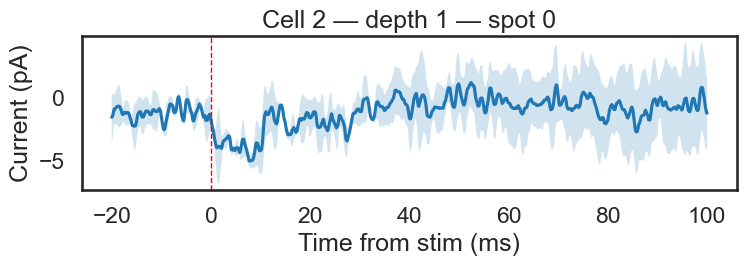

In [6]:
# Quick plot of the spot's opto trace(s)
opto = resp["traces"]["opto"]["search_0"]   # (n_sweeps, n_samples)
output_fs = resp["meta"]["output_fs"]
t_ms = (np.arange(opto.shape[1]) - resp["meta"]["event_sample"] + 1) / (output_fs / 1000)

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ndap.plot_sem(opto, t_ms, color='tab:blue', ax=ax)
ax.axvline(0, color="r", ls="--", lw=1)
ax.set_xlabel("Time from stim (ms)")
ax.set_ylabel("Current (pA)")
ax.set_title(f"Cell {cell} — depth {depth} — spot {hotspot}")
plt.tight_layout()
plt.show()

## 3. Tidy long-format DataFrame of all spots

In [7]:
# long_df = ndap.results_to_long_dataframe(cells_df)
# print(f"Shape: {long_df.shape}")
# long_df.head(8)

# Hotspot distribution across all cells / searches / depths
# print(long_df.groupby(["cell", "depth"])["is_hotspot"].sum().unstack("depth").to_string())

## 4. Analyze a single search — `analyze_dmd_search`

Produces one summary figure per depth with:
- Tiled per-spot trace grid (hotspots highlighted)
- Response map image
- Opto vs. baseline trace overlay
- AUC and response-rate scatter-bar plots

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out

Depths analysed: 5
  depth 1: 2/4 hotspots
  depth 2: 5/8 hotspots
  depth 3: 2/16 hotspots
  depth 4: 1/8 hotspots
  depth 5: 0/4 hotspots


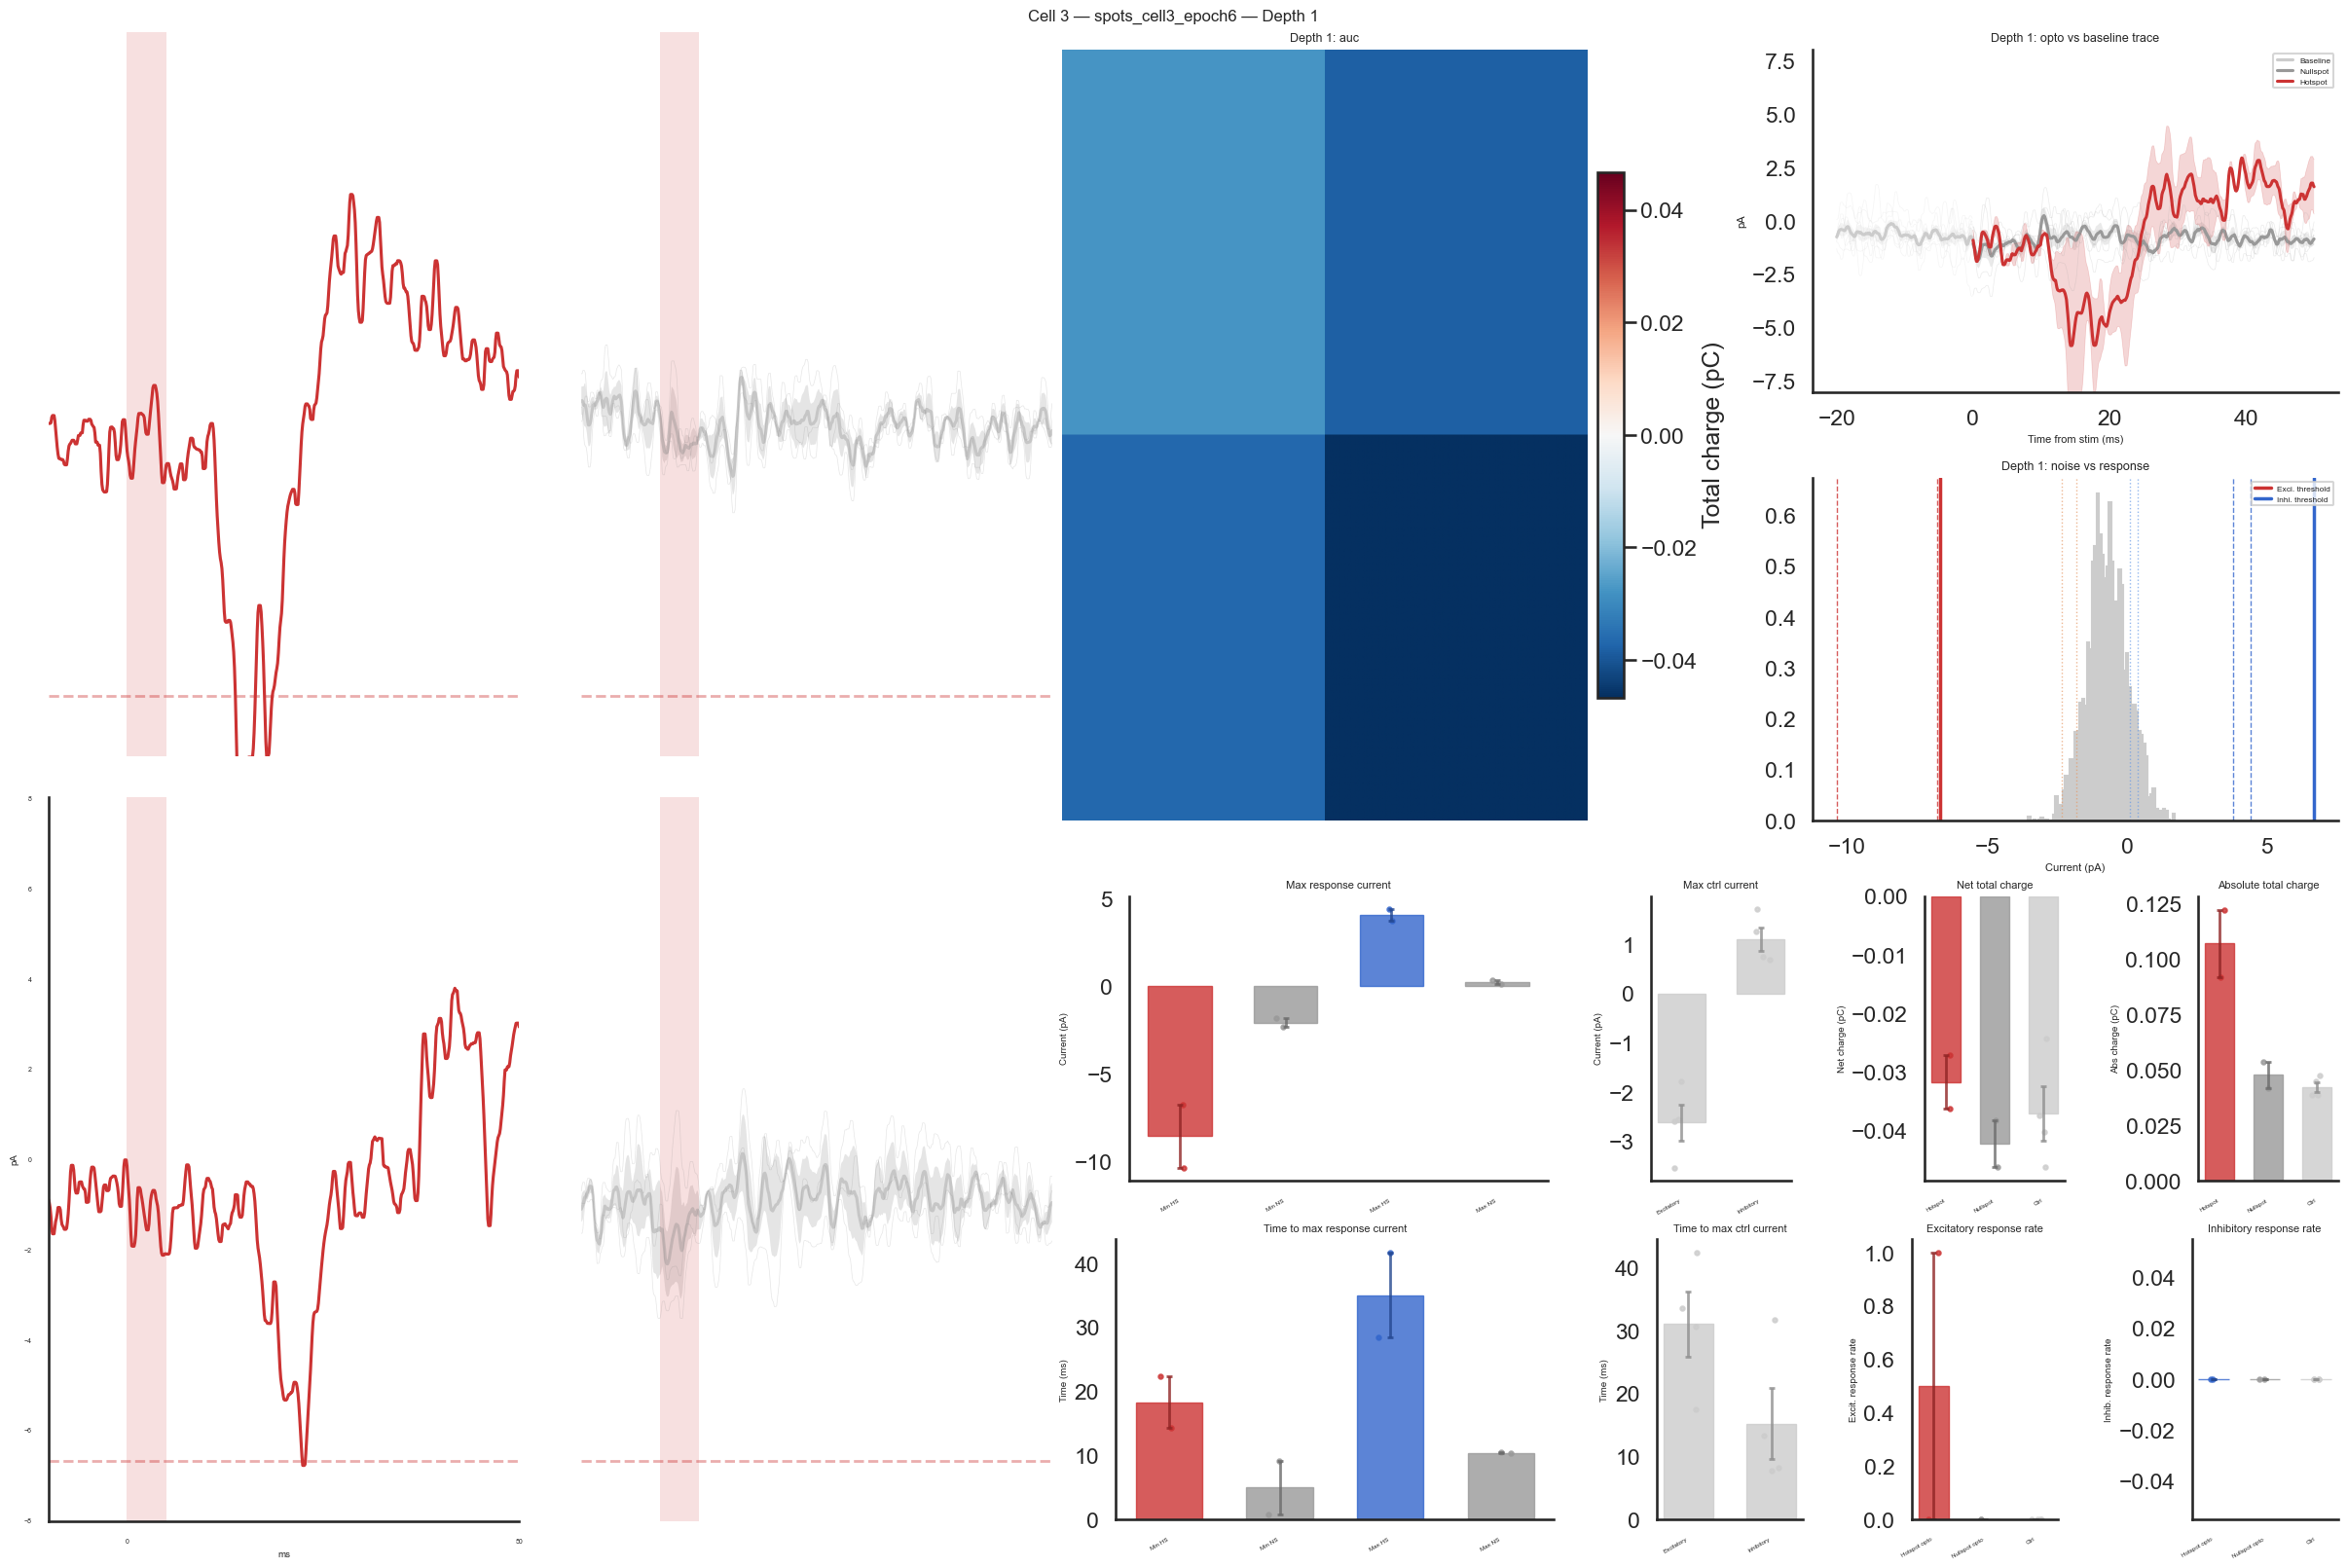

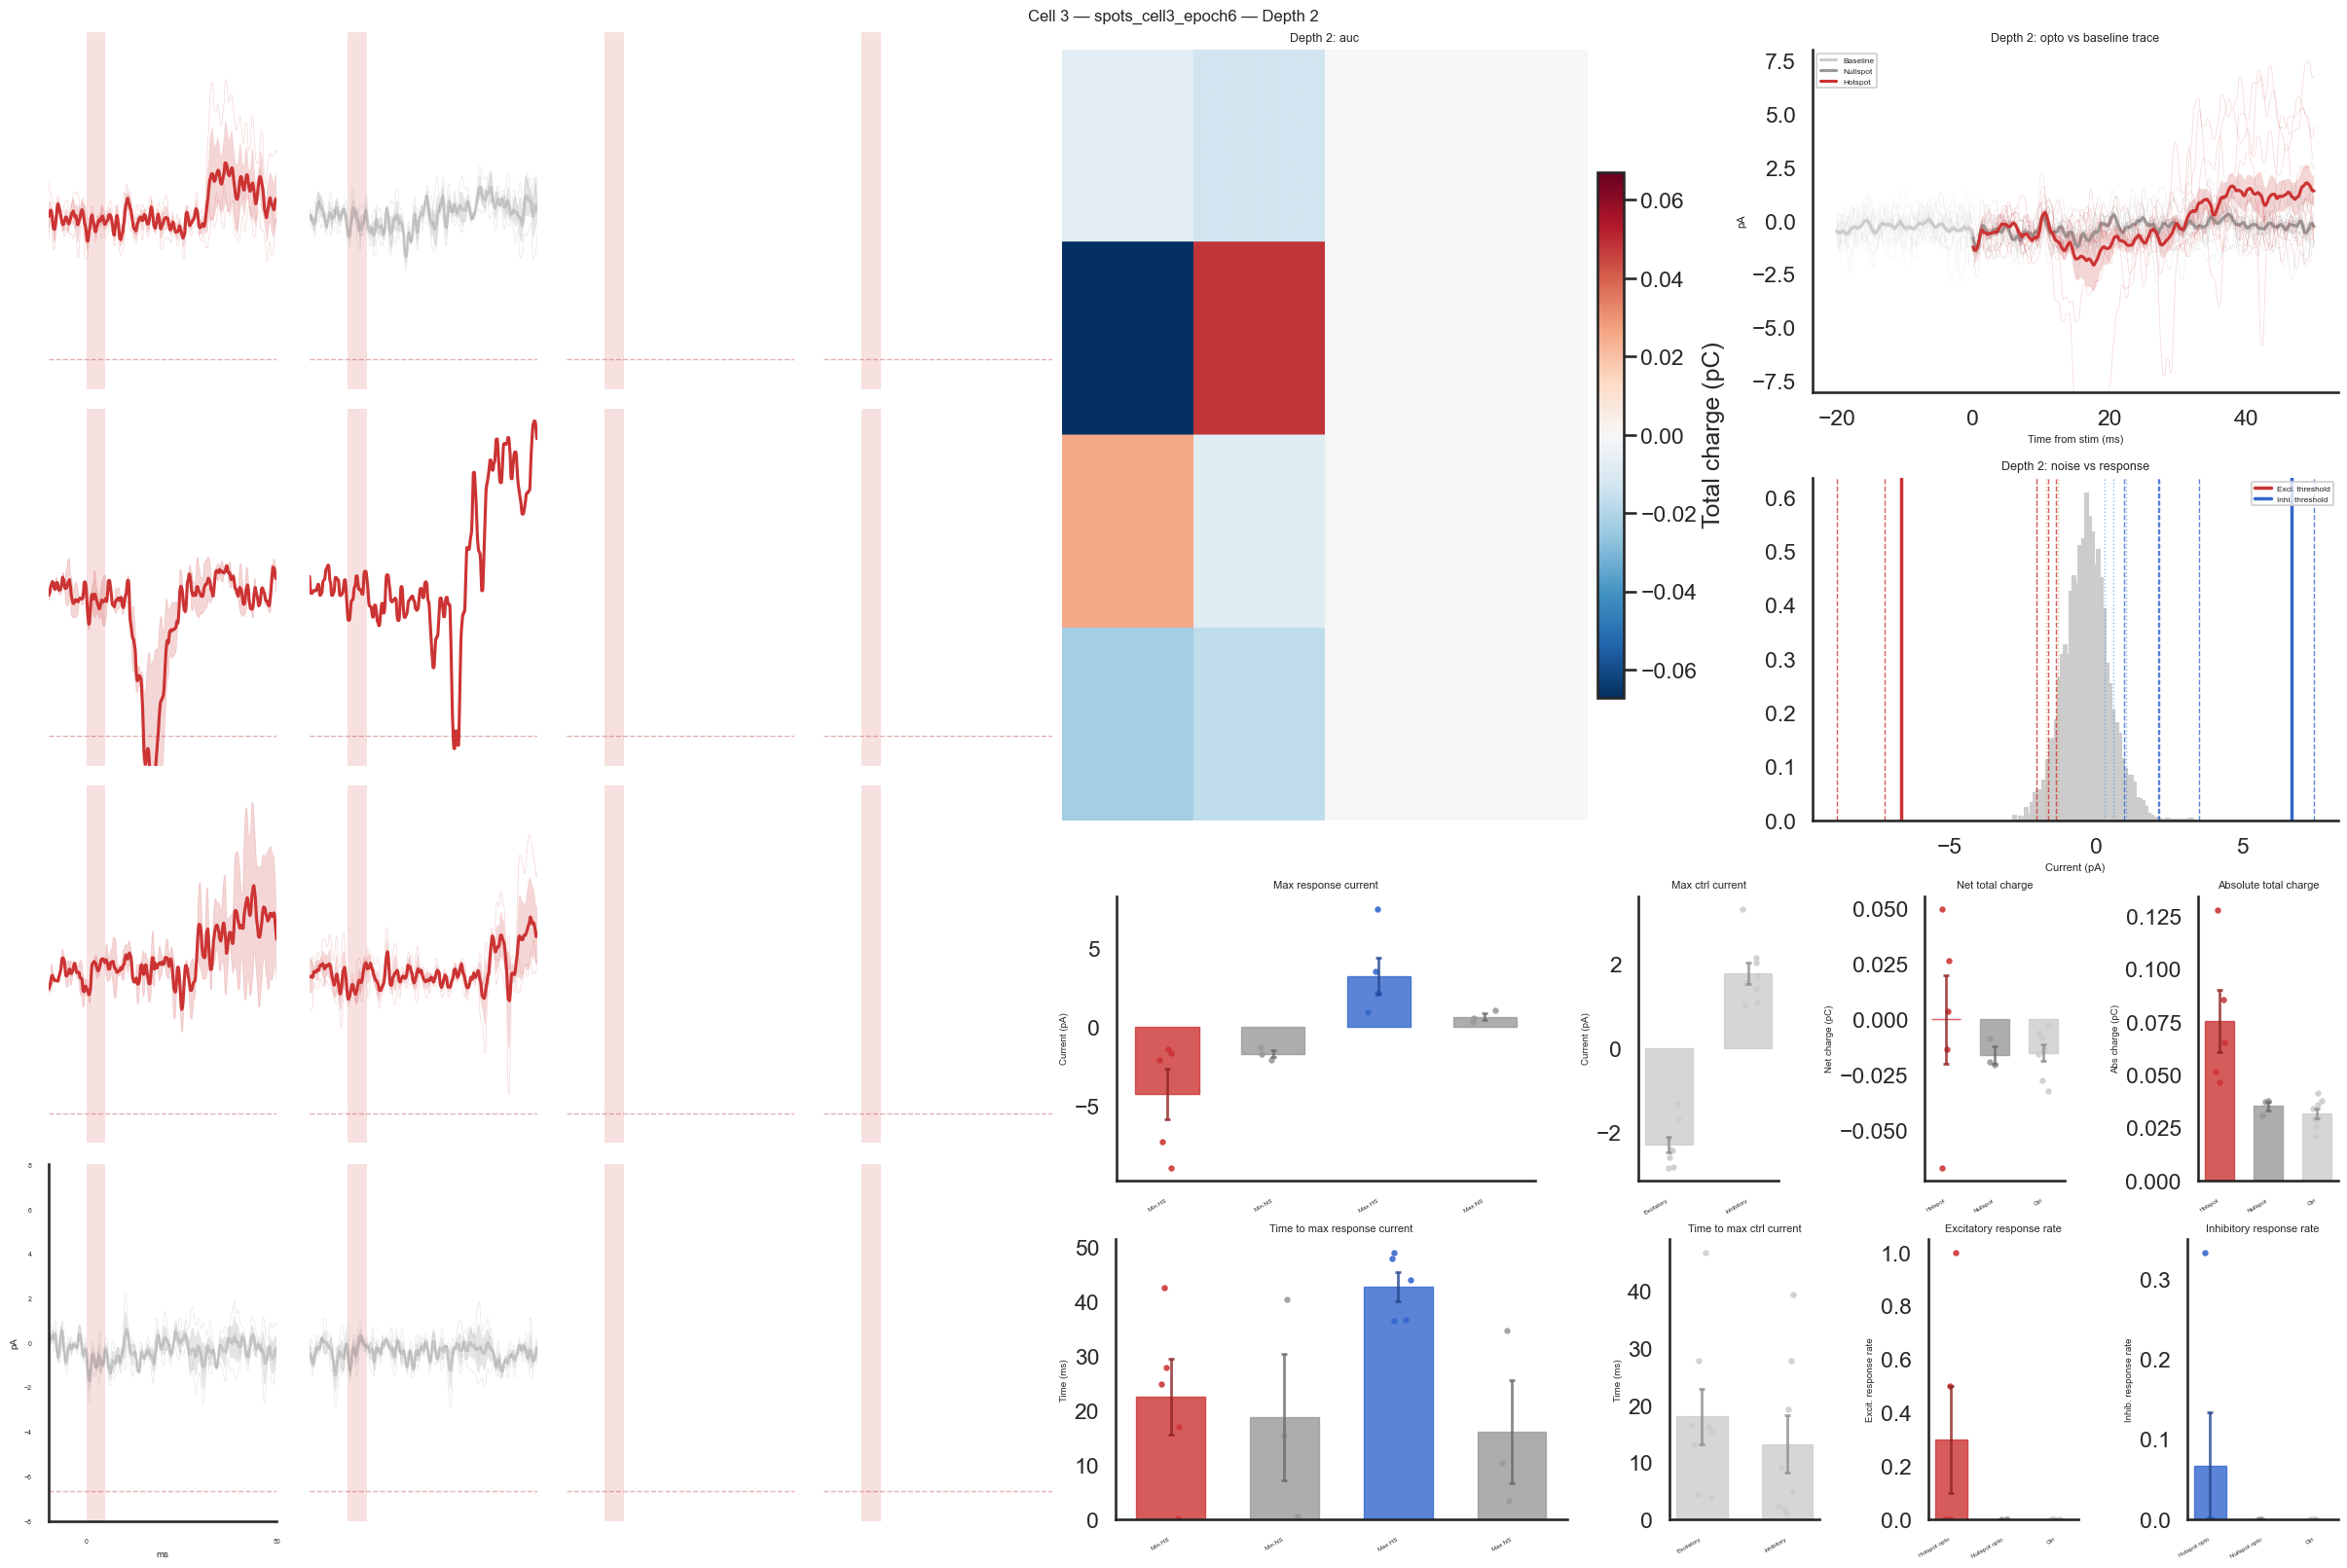

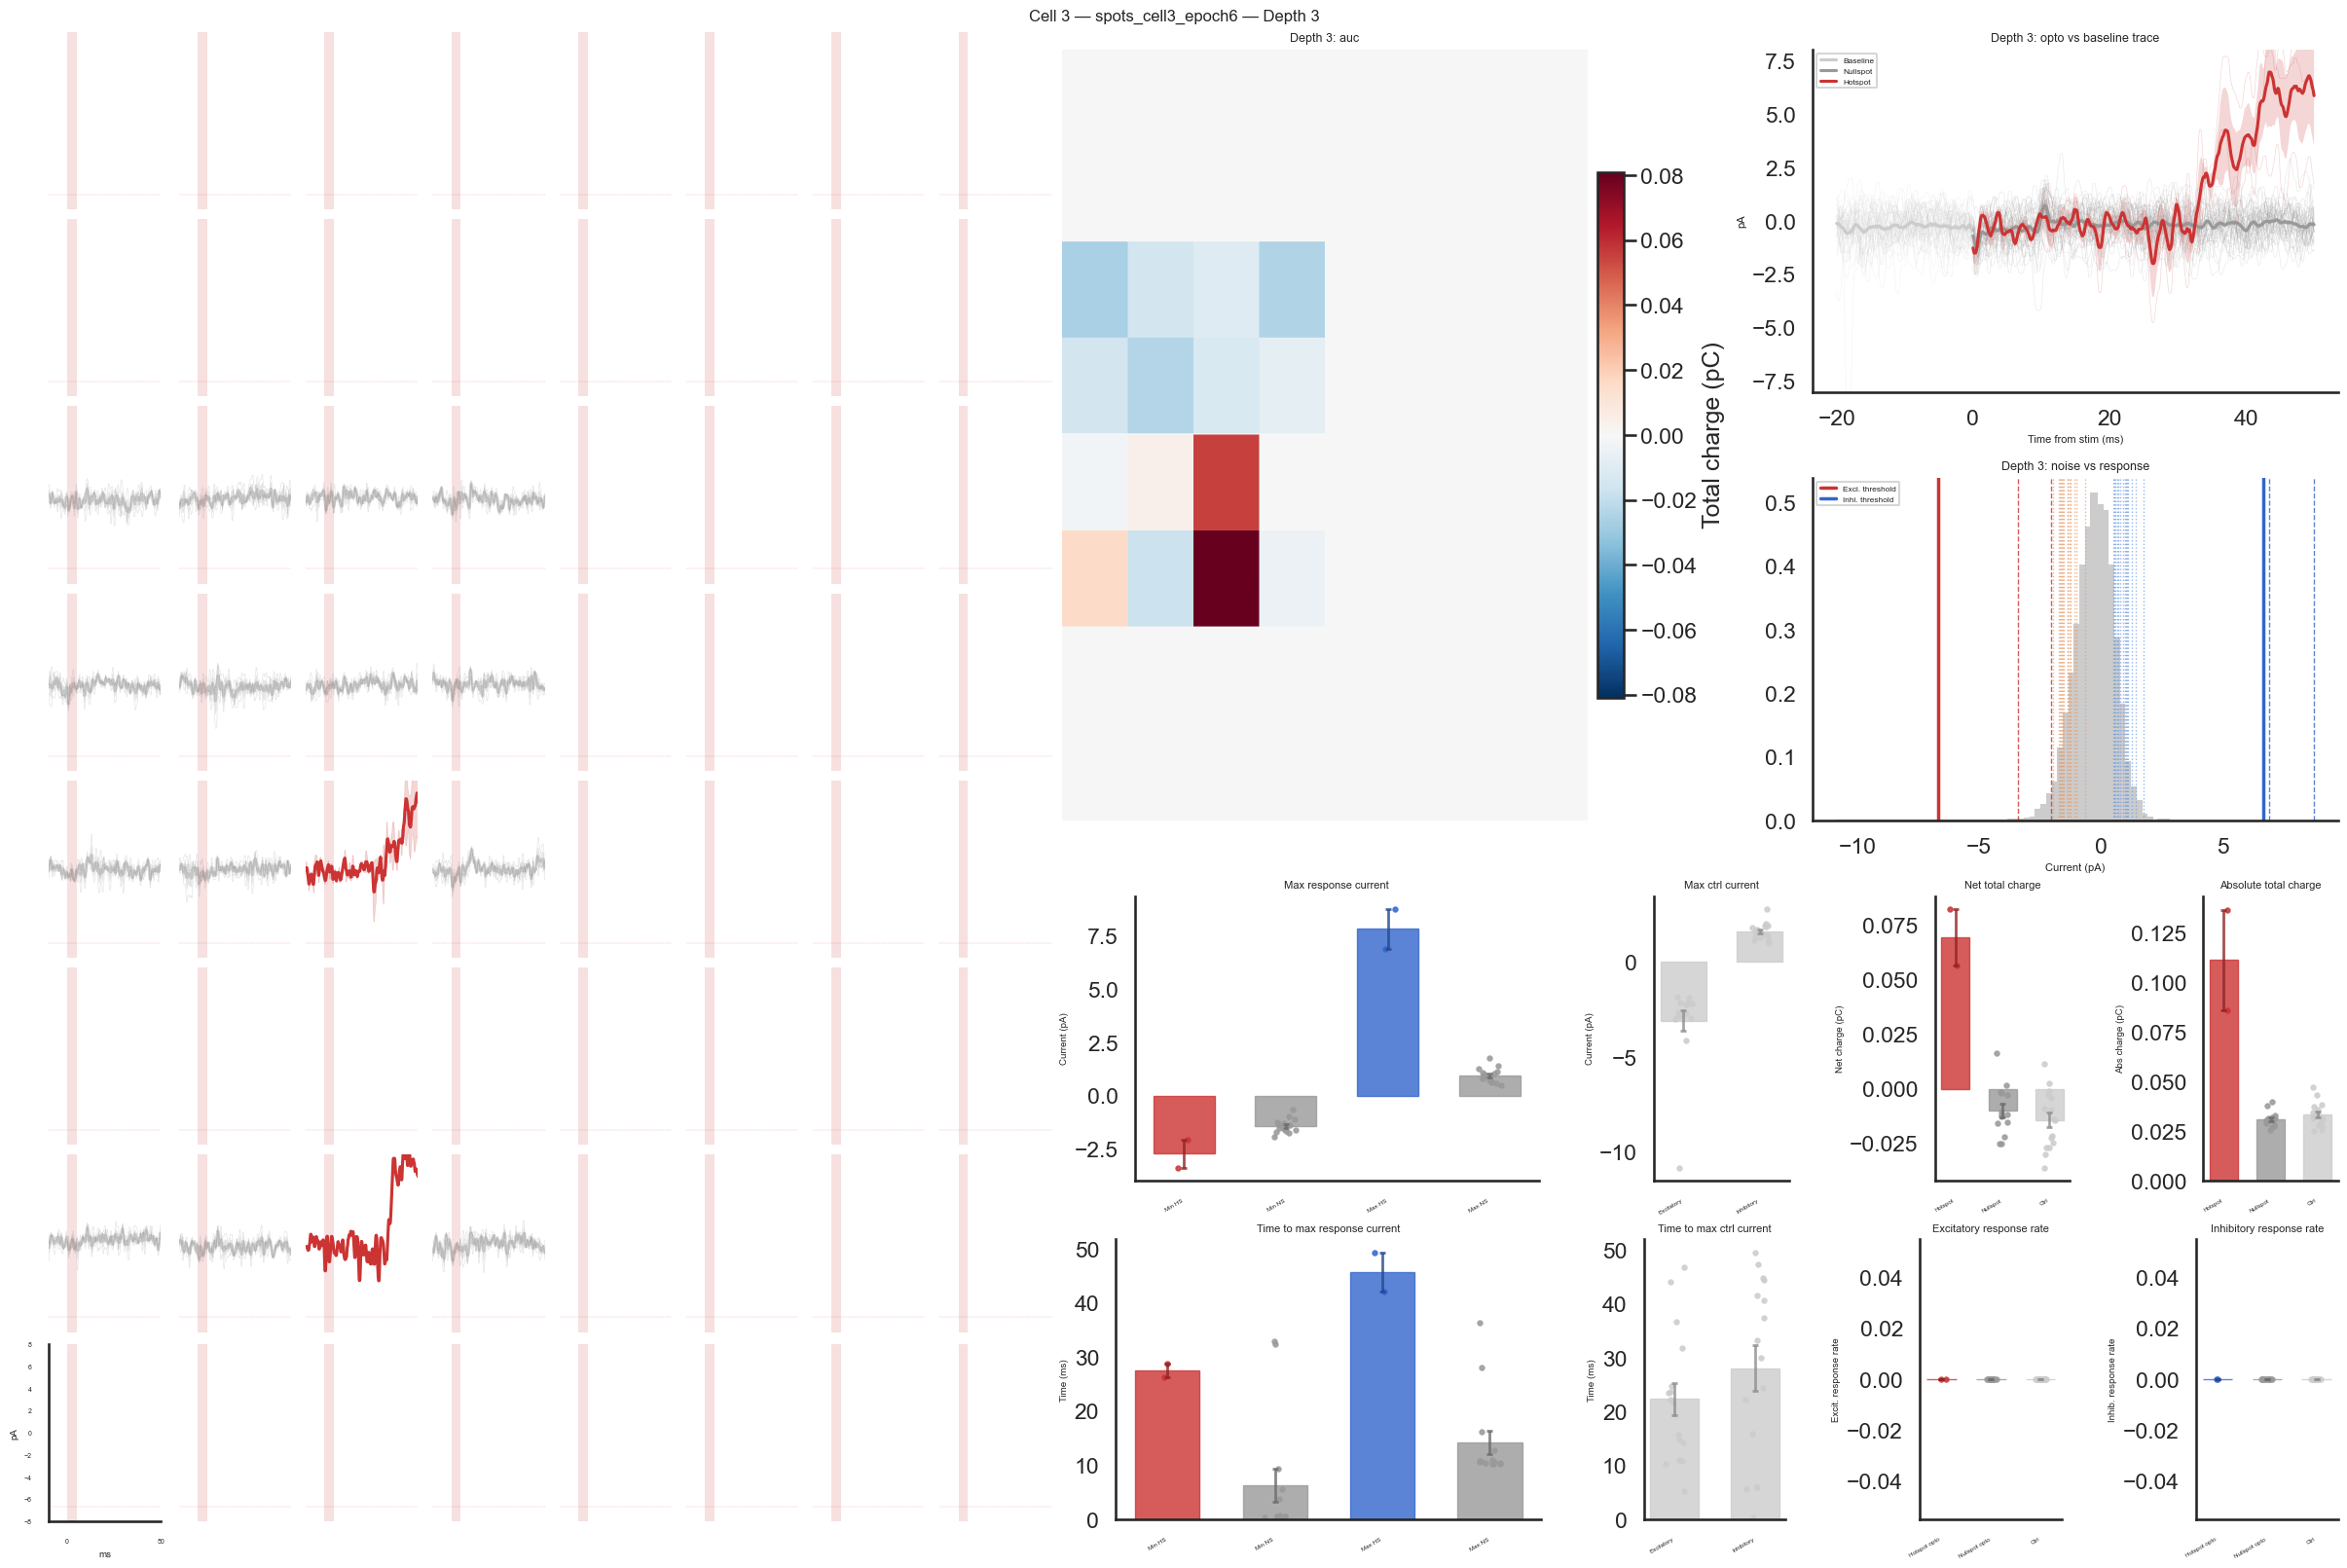

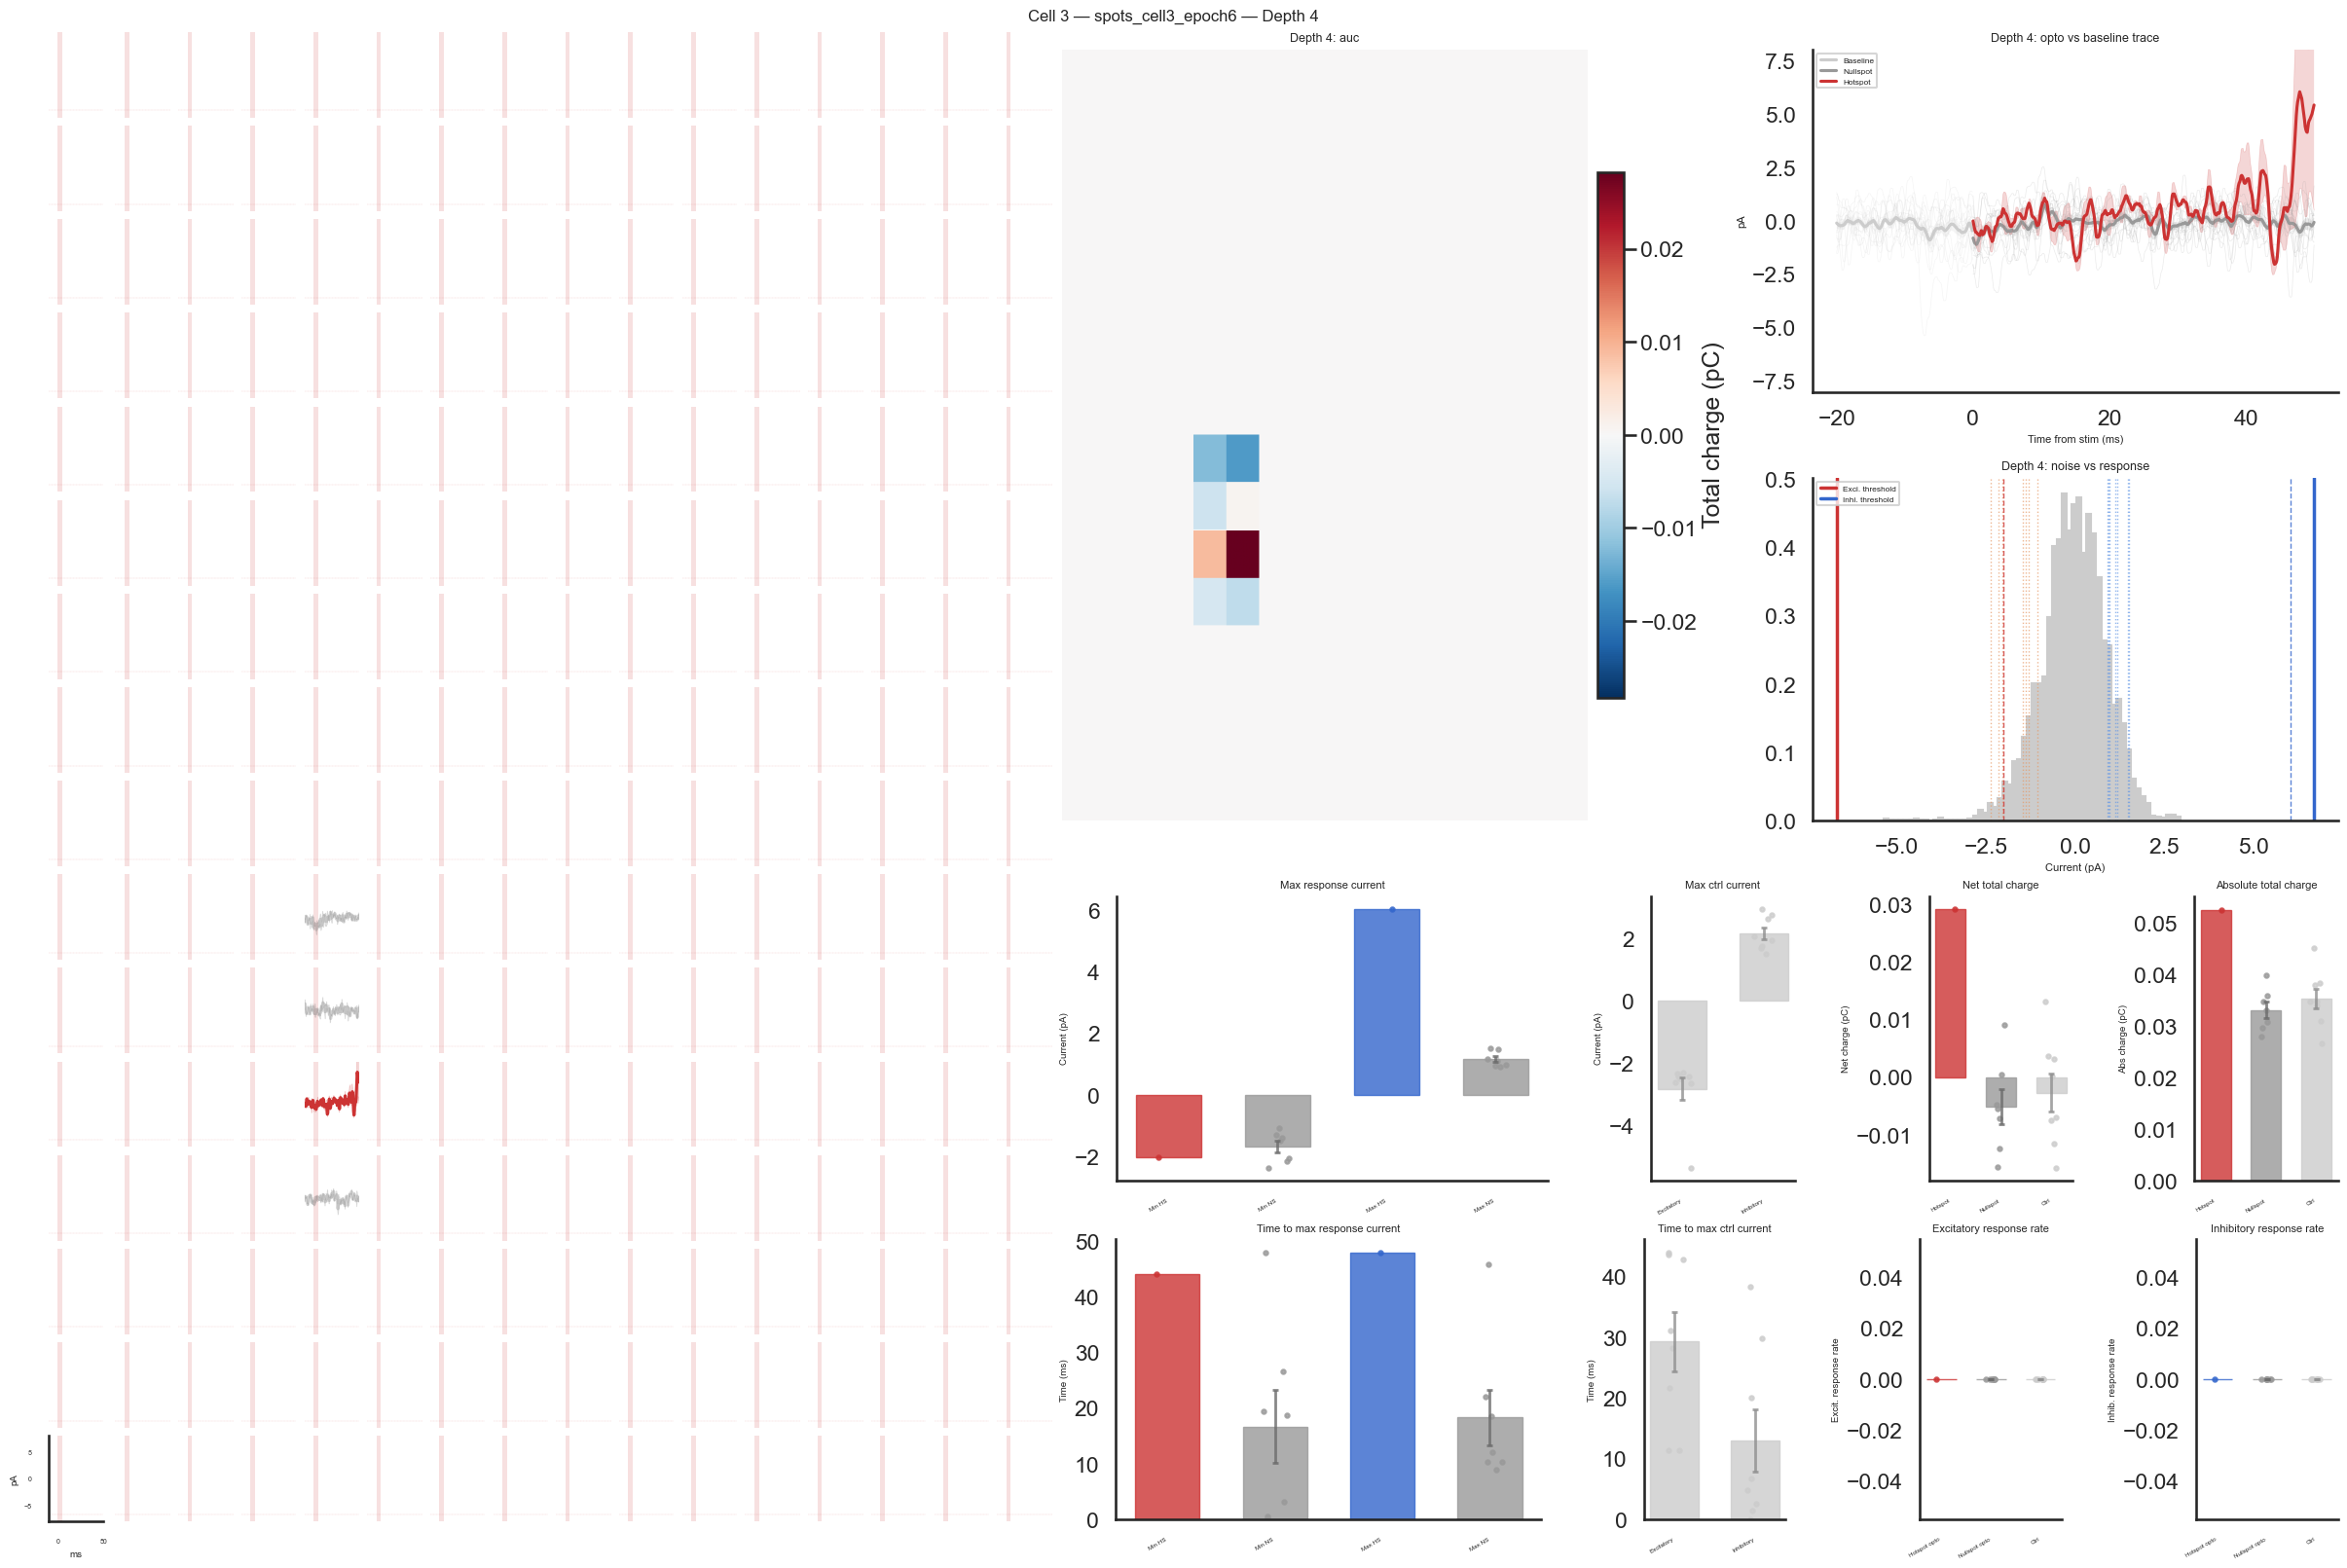

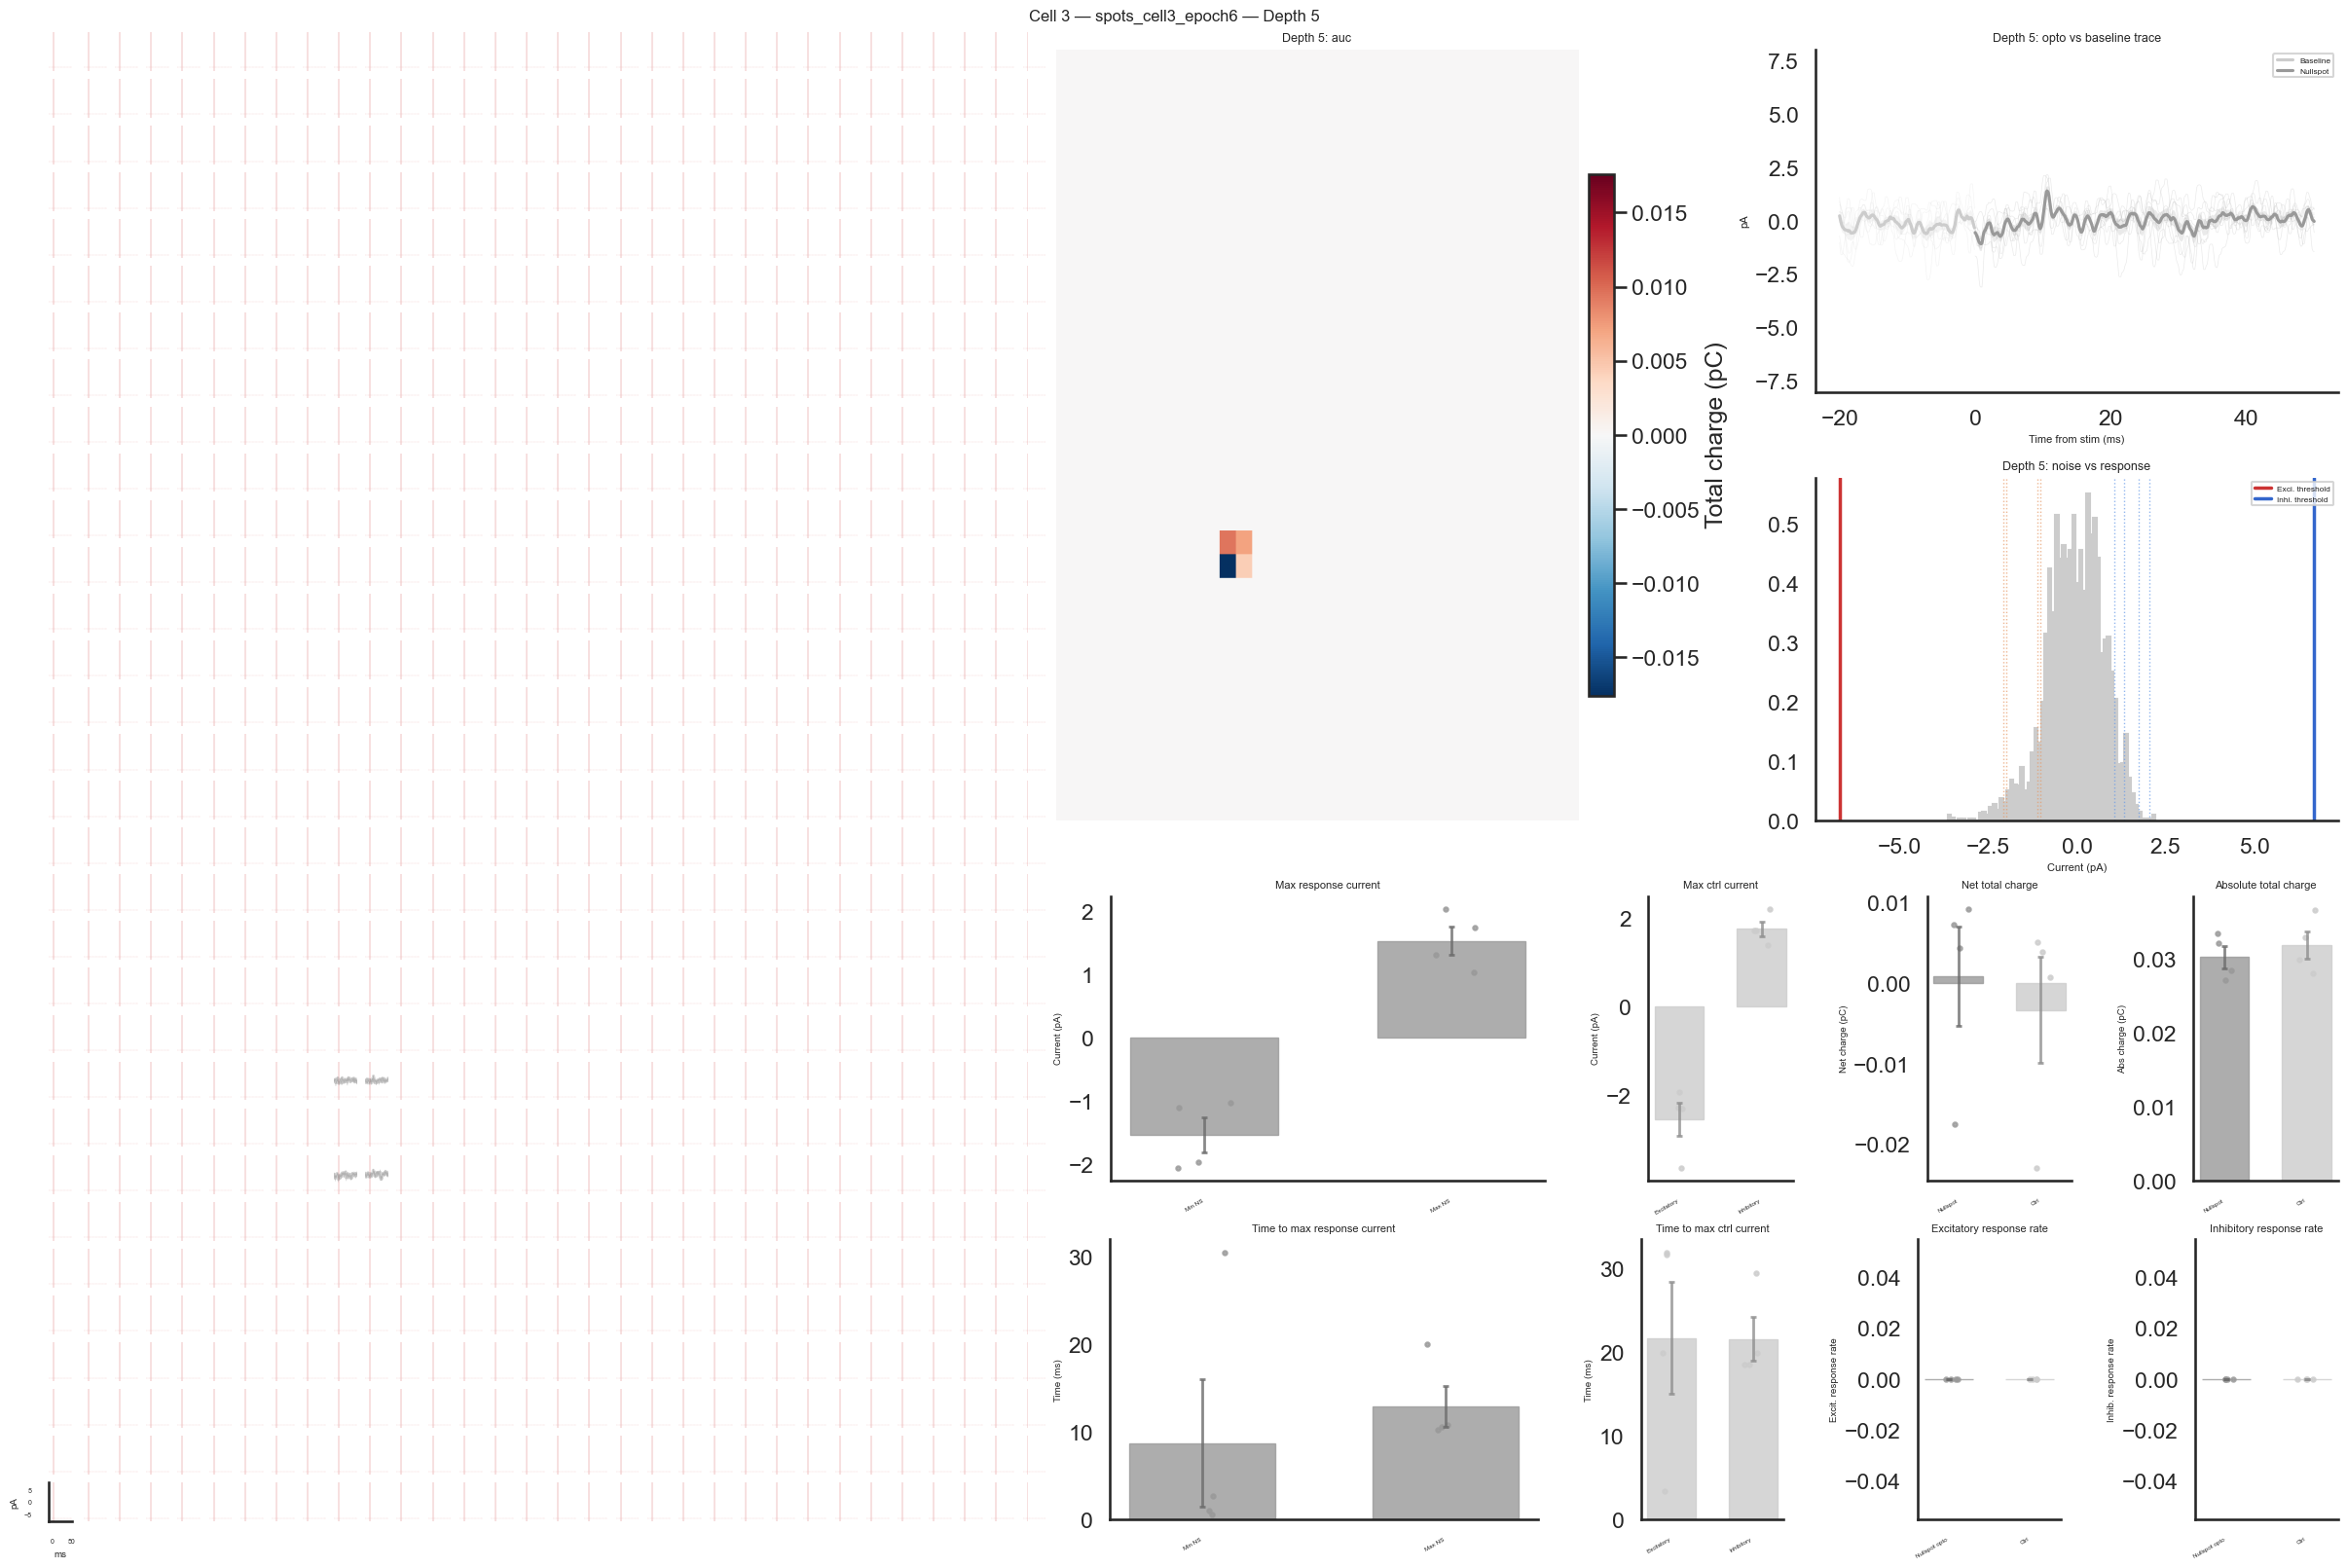

In [8]:
search_result = ndap.analyze_dmd_search(
    cells_df,
    cell=3,
    search_idx=0,
    make_plots=True,
    save_dir=SAVE_DIR,
)

print(f"Depths analysed: {len(search_result['depth_results'])}")
for dr in search_result["depth_results"]:
    n_hs = dr["hotspot_spot_idx"].sum()
    n_tot = len(dr["hotspot_spot_idx"])
    print(f"  depth {dr['depth']}: {n_hs}/{n_tot} hotspots")

In [9]:
# Per-depth metrics summary
metrics = search_result["metrics_df"]
metrics.groupby("depth")[["auc", "ctrl_auc", "e_rate", "i_rate"]].mean().round(4)

,auc,ctrl_auc,e_rate,i_rate
depth,,,,
1,-0.0369,-0.0370,0.2500,0.0000
2,-0.0061,-0.0151,0.1875,0.0417
3,-0.0000,-0.0144,0.0000,0.0000
4,-0.0008,-0.0027,0.0000,0.0000
5,0.0009,-0.0033,0.0000,0.0000


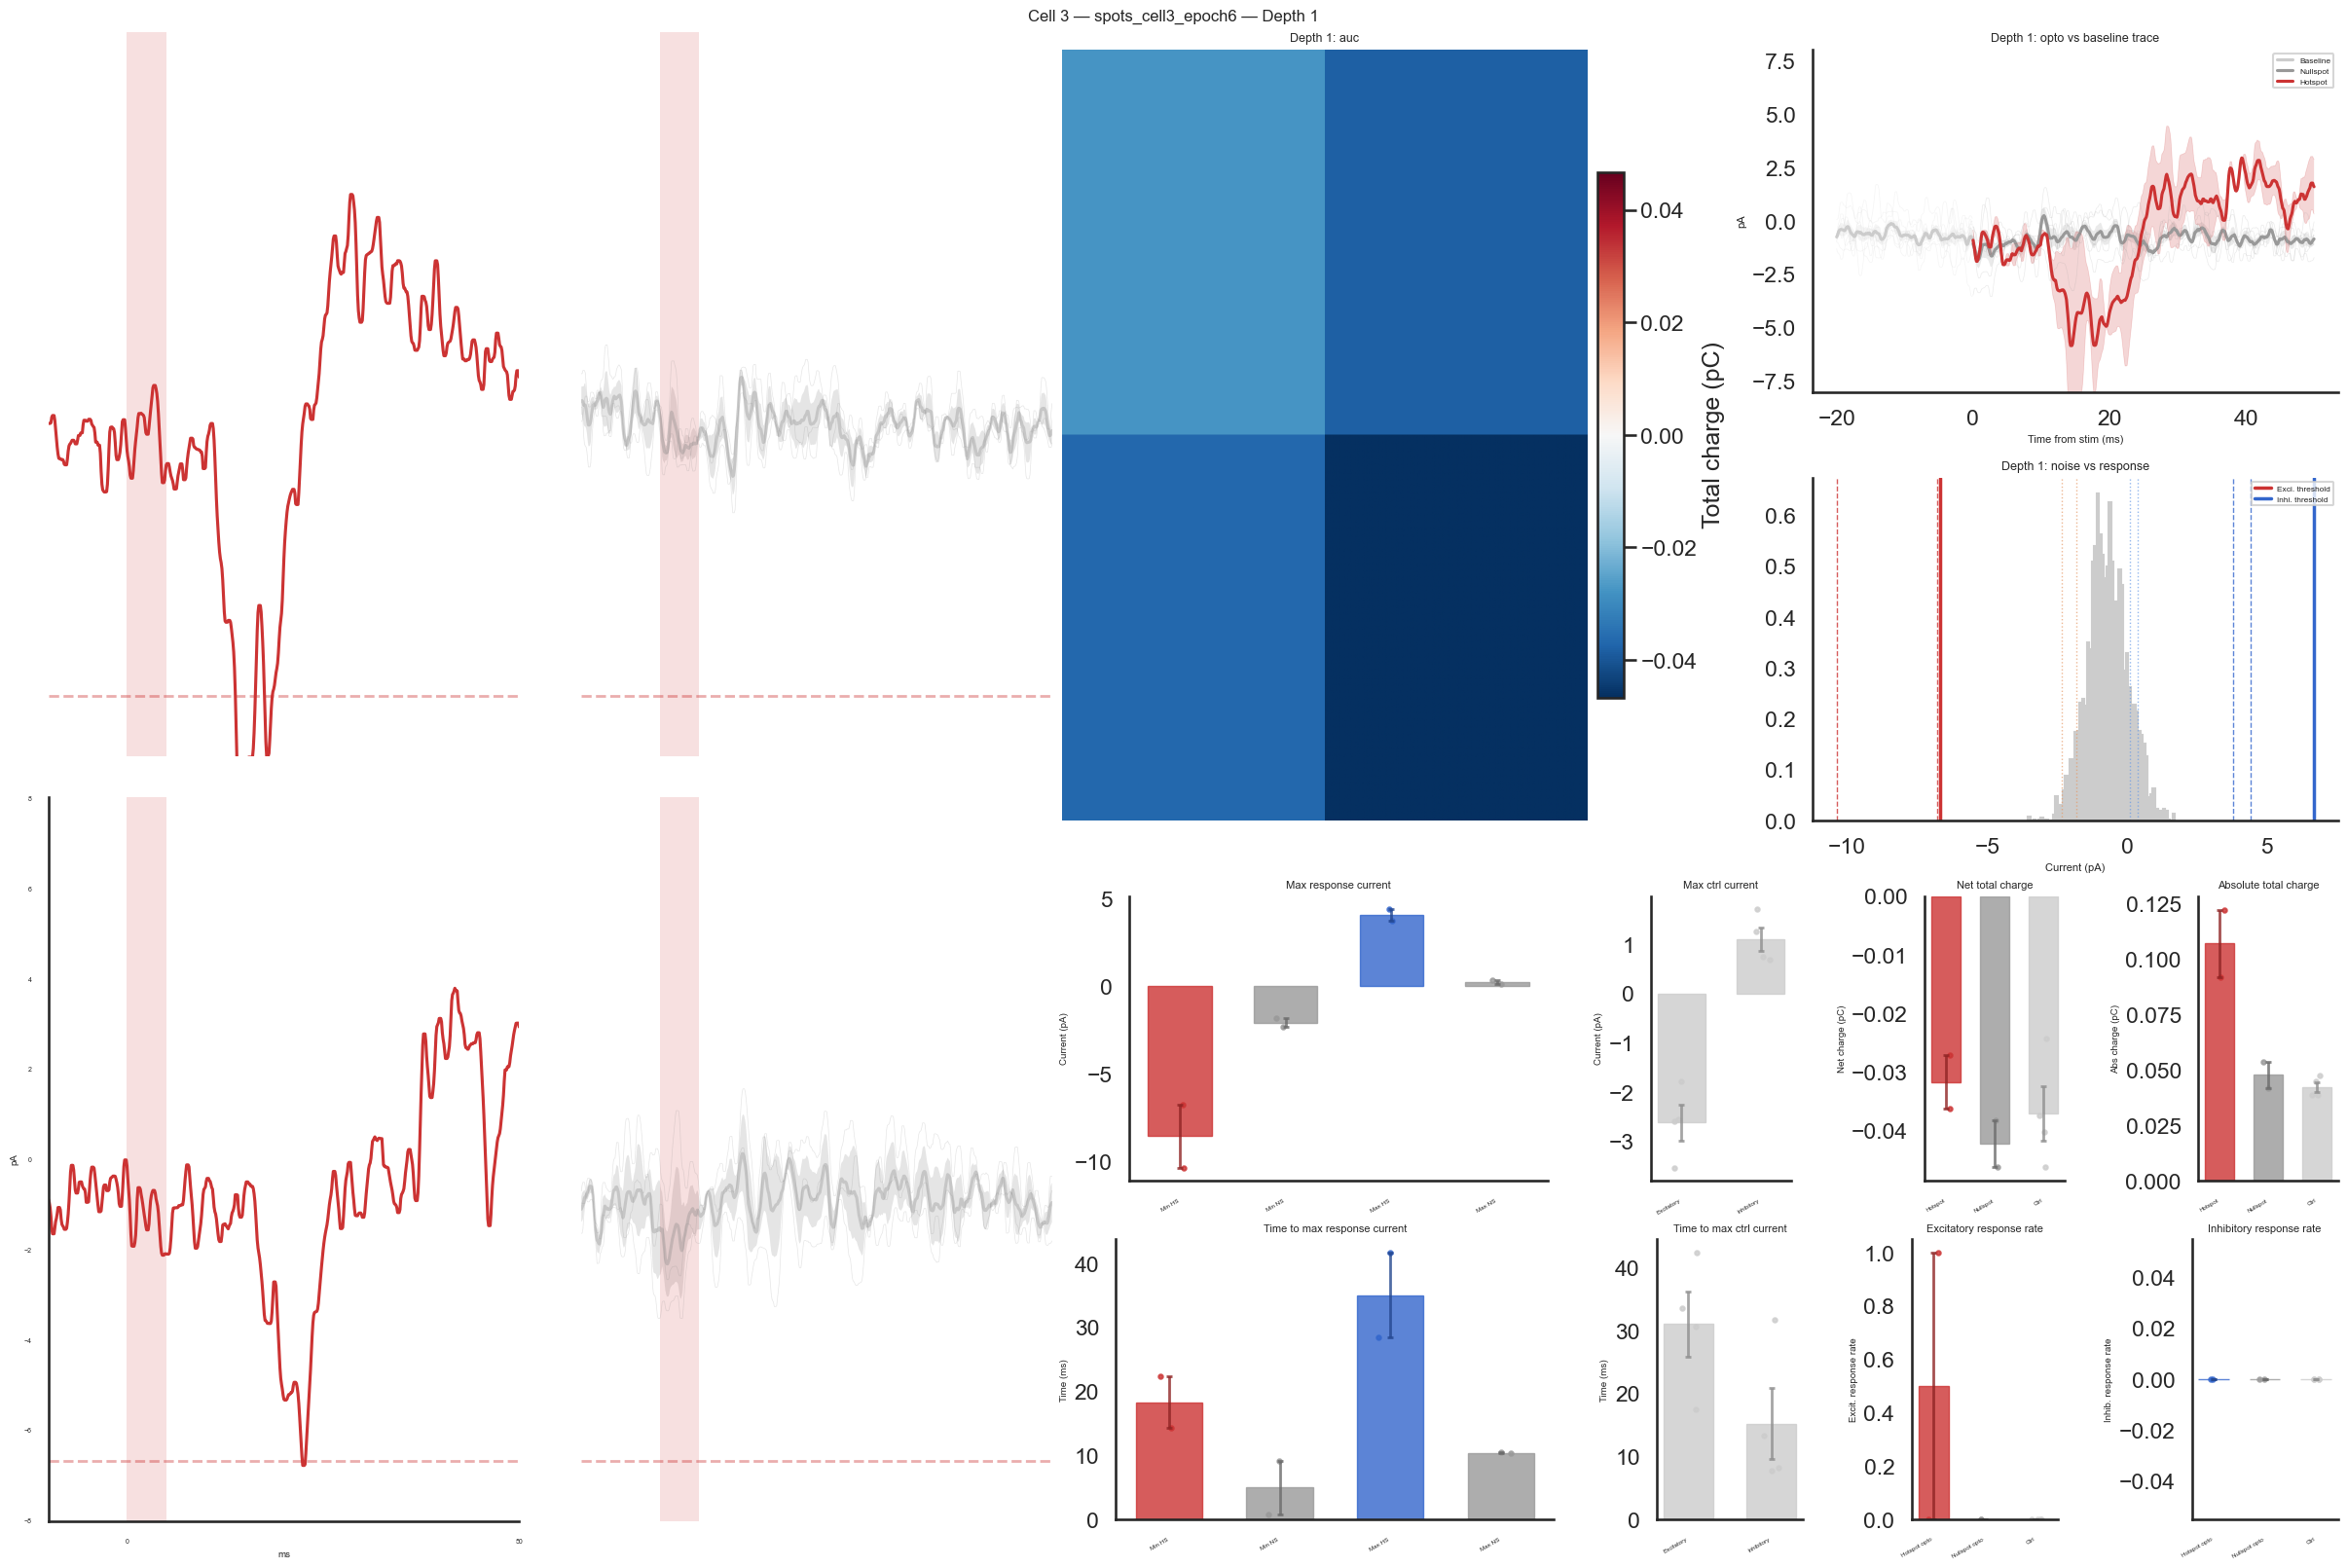

In [10]:
# Display the figure for depth 1
search_result["figures"][0]

## 5. Paired search comparison — `analyze_dmd_search_pair`

Cell 2 has two searches (`epoch8` and `epoch9`), which form one pair.
This computes per-common-depth AUC differences and comparison figures.

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out

Common depths compared: 3
  depth 1: opto1=(9, 501), opto2=(10, 501)
  depth 2: opto1=(33, 501), opto2=(30, 501)
  depth 3: opto1=(24, 501), opto2=(36, 501)


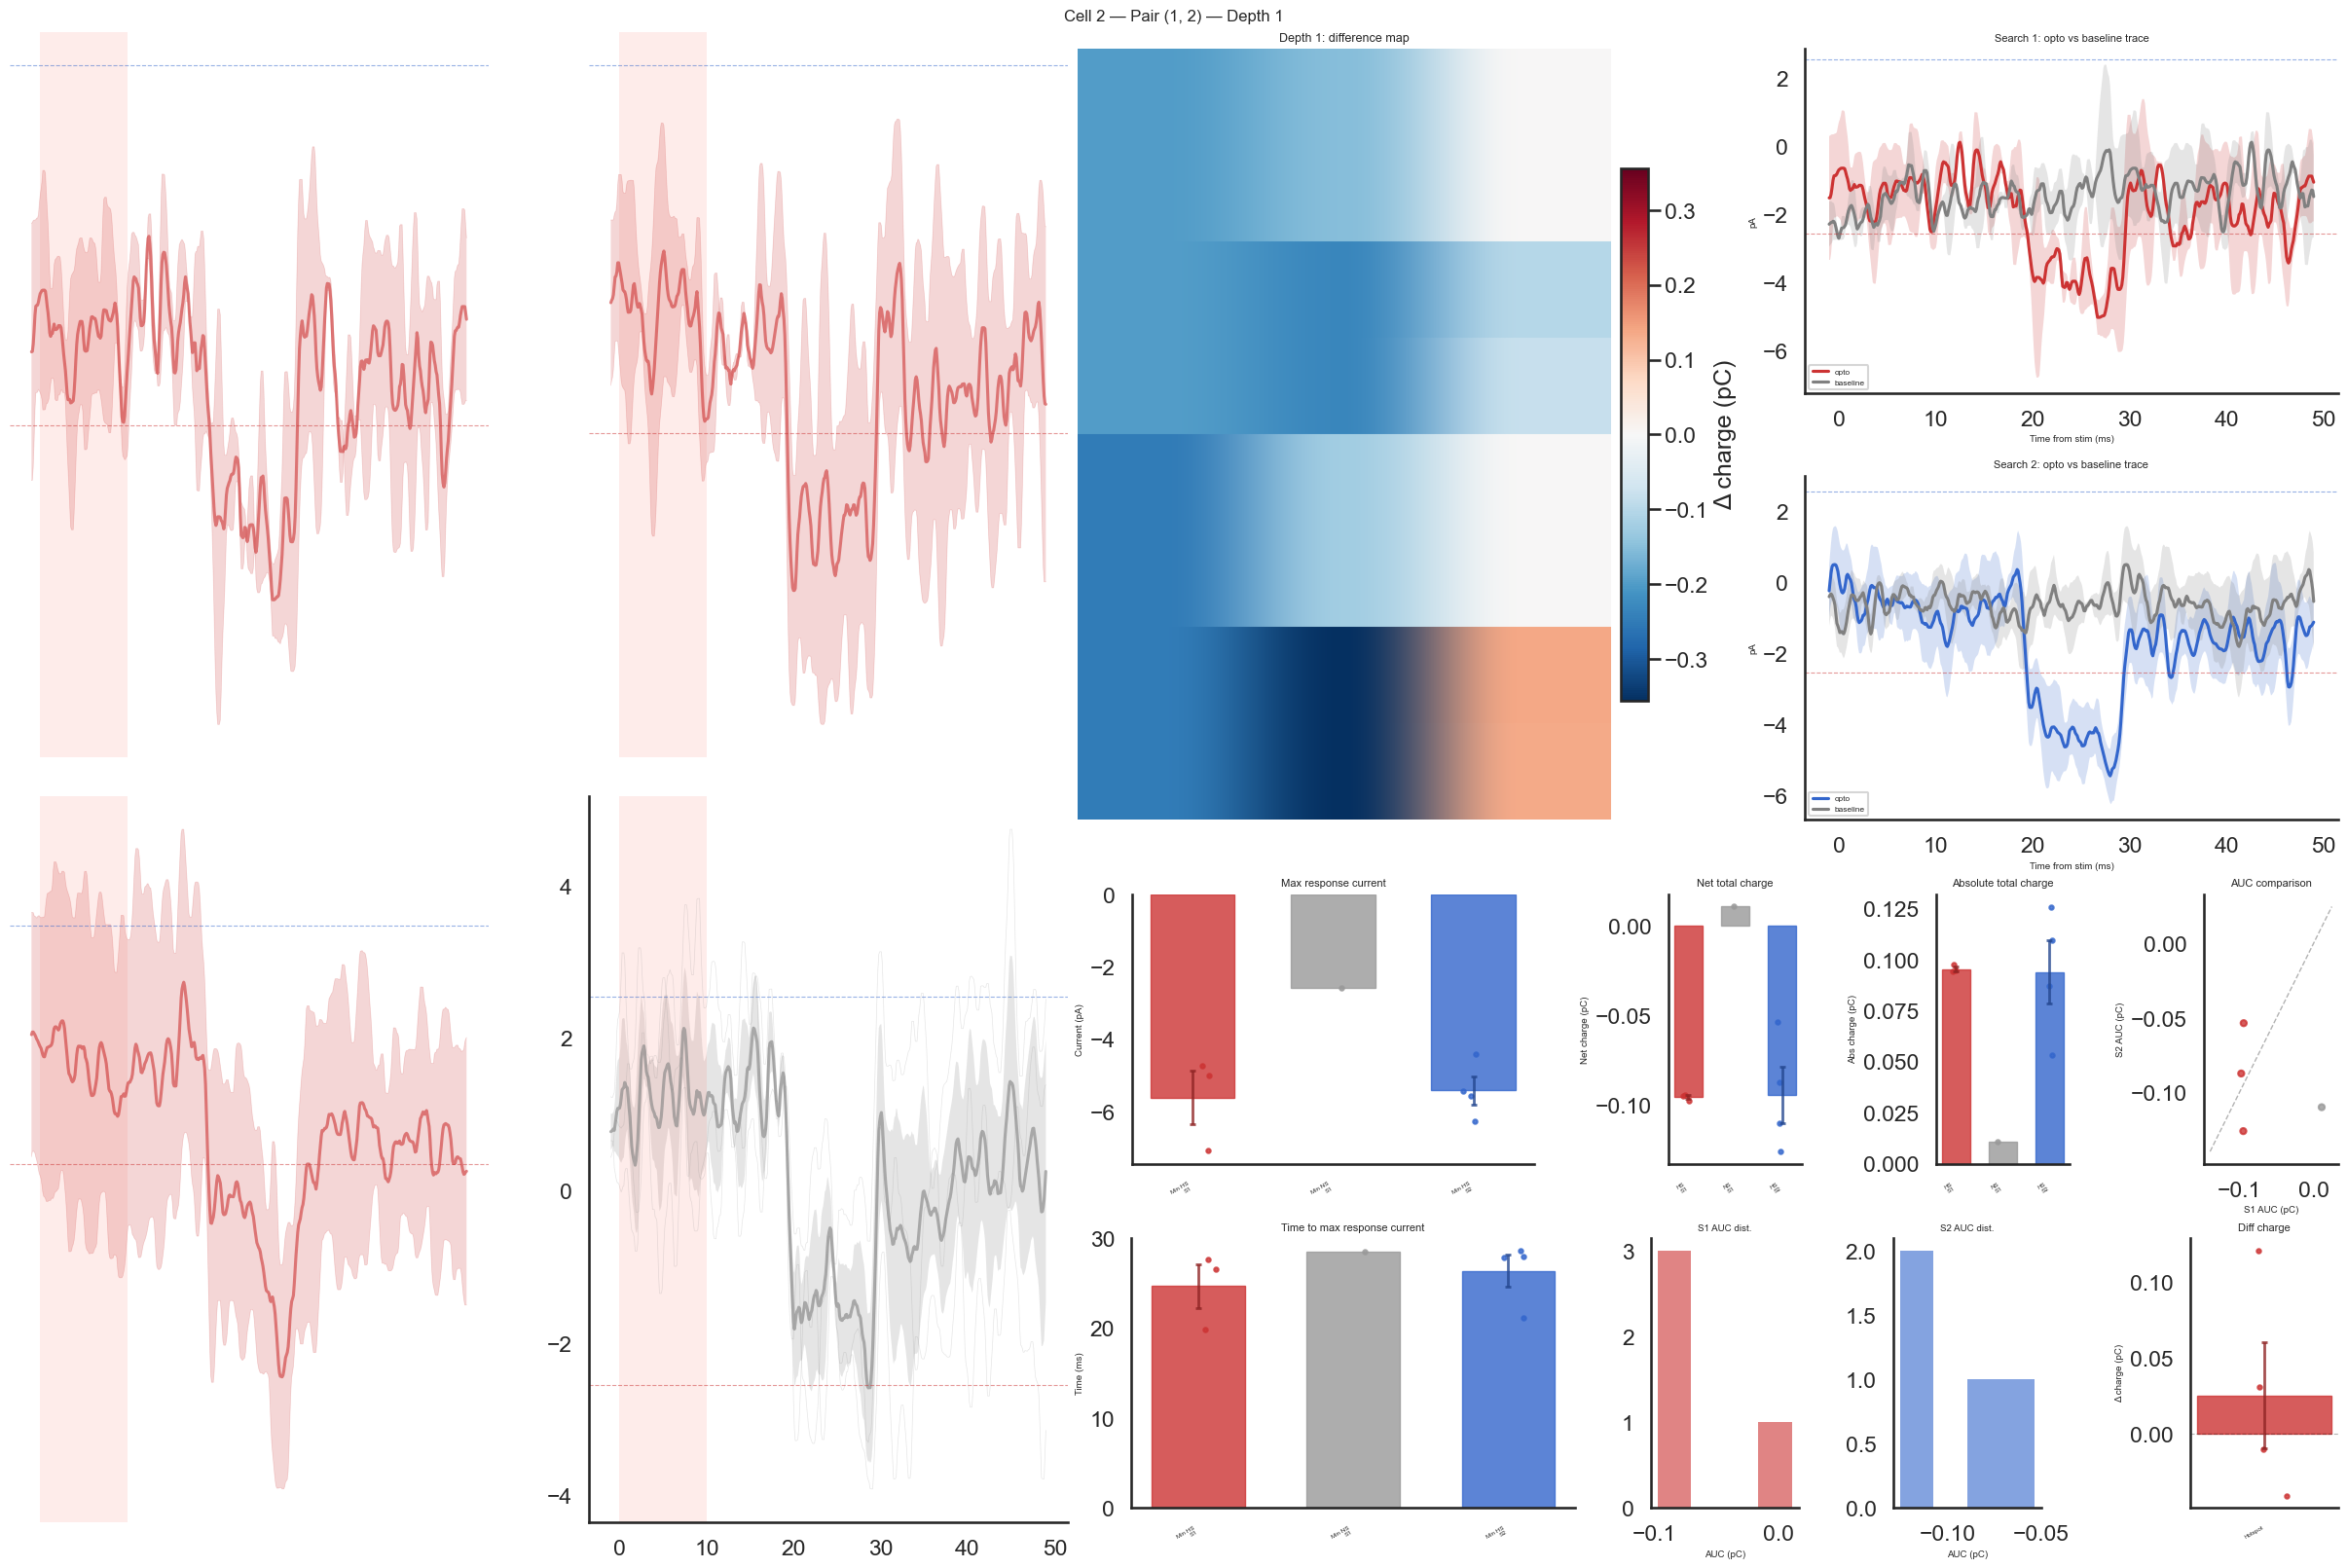

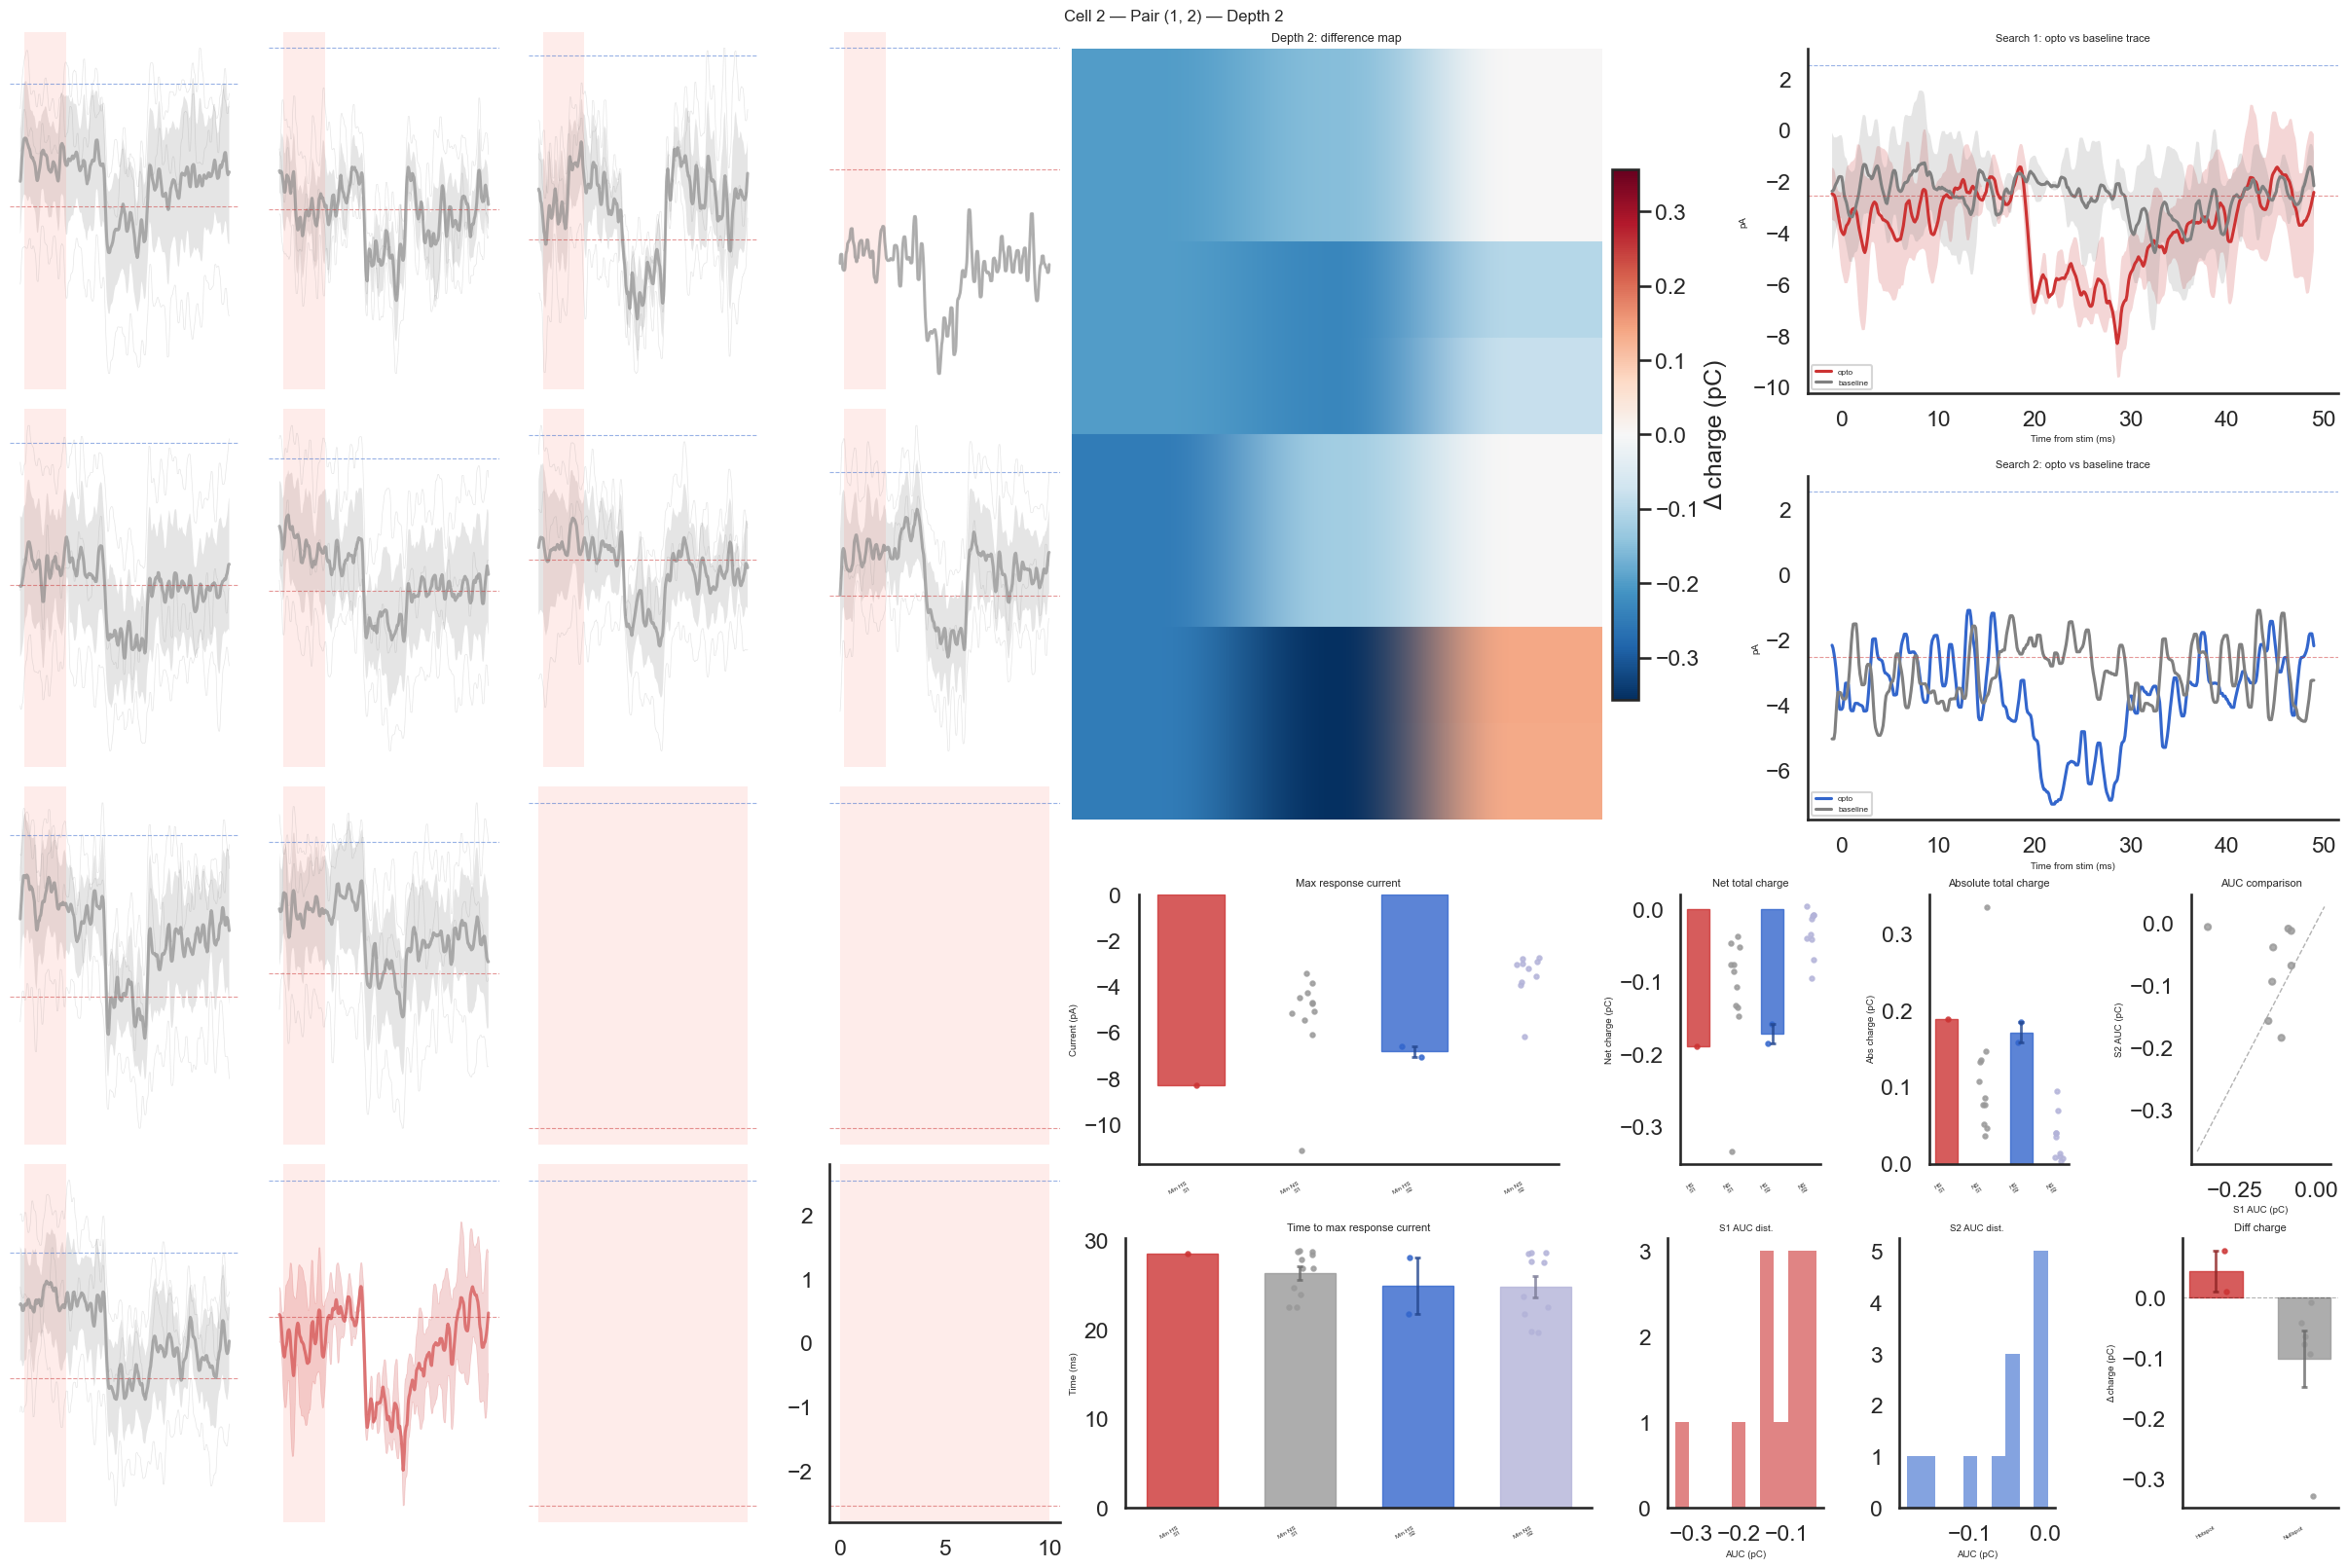

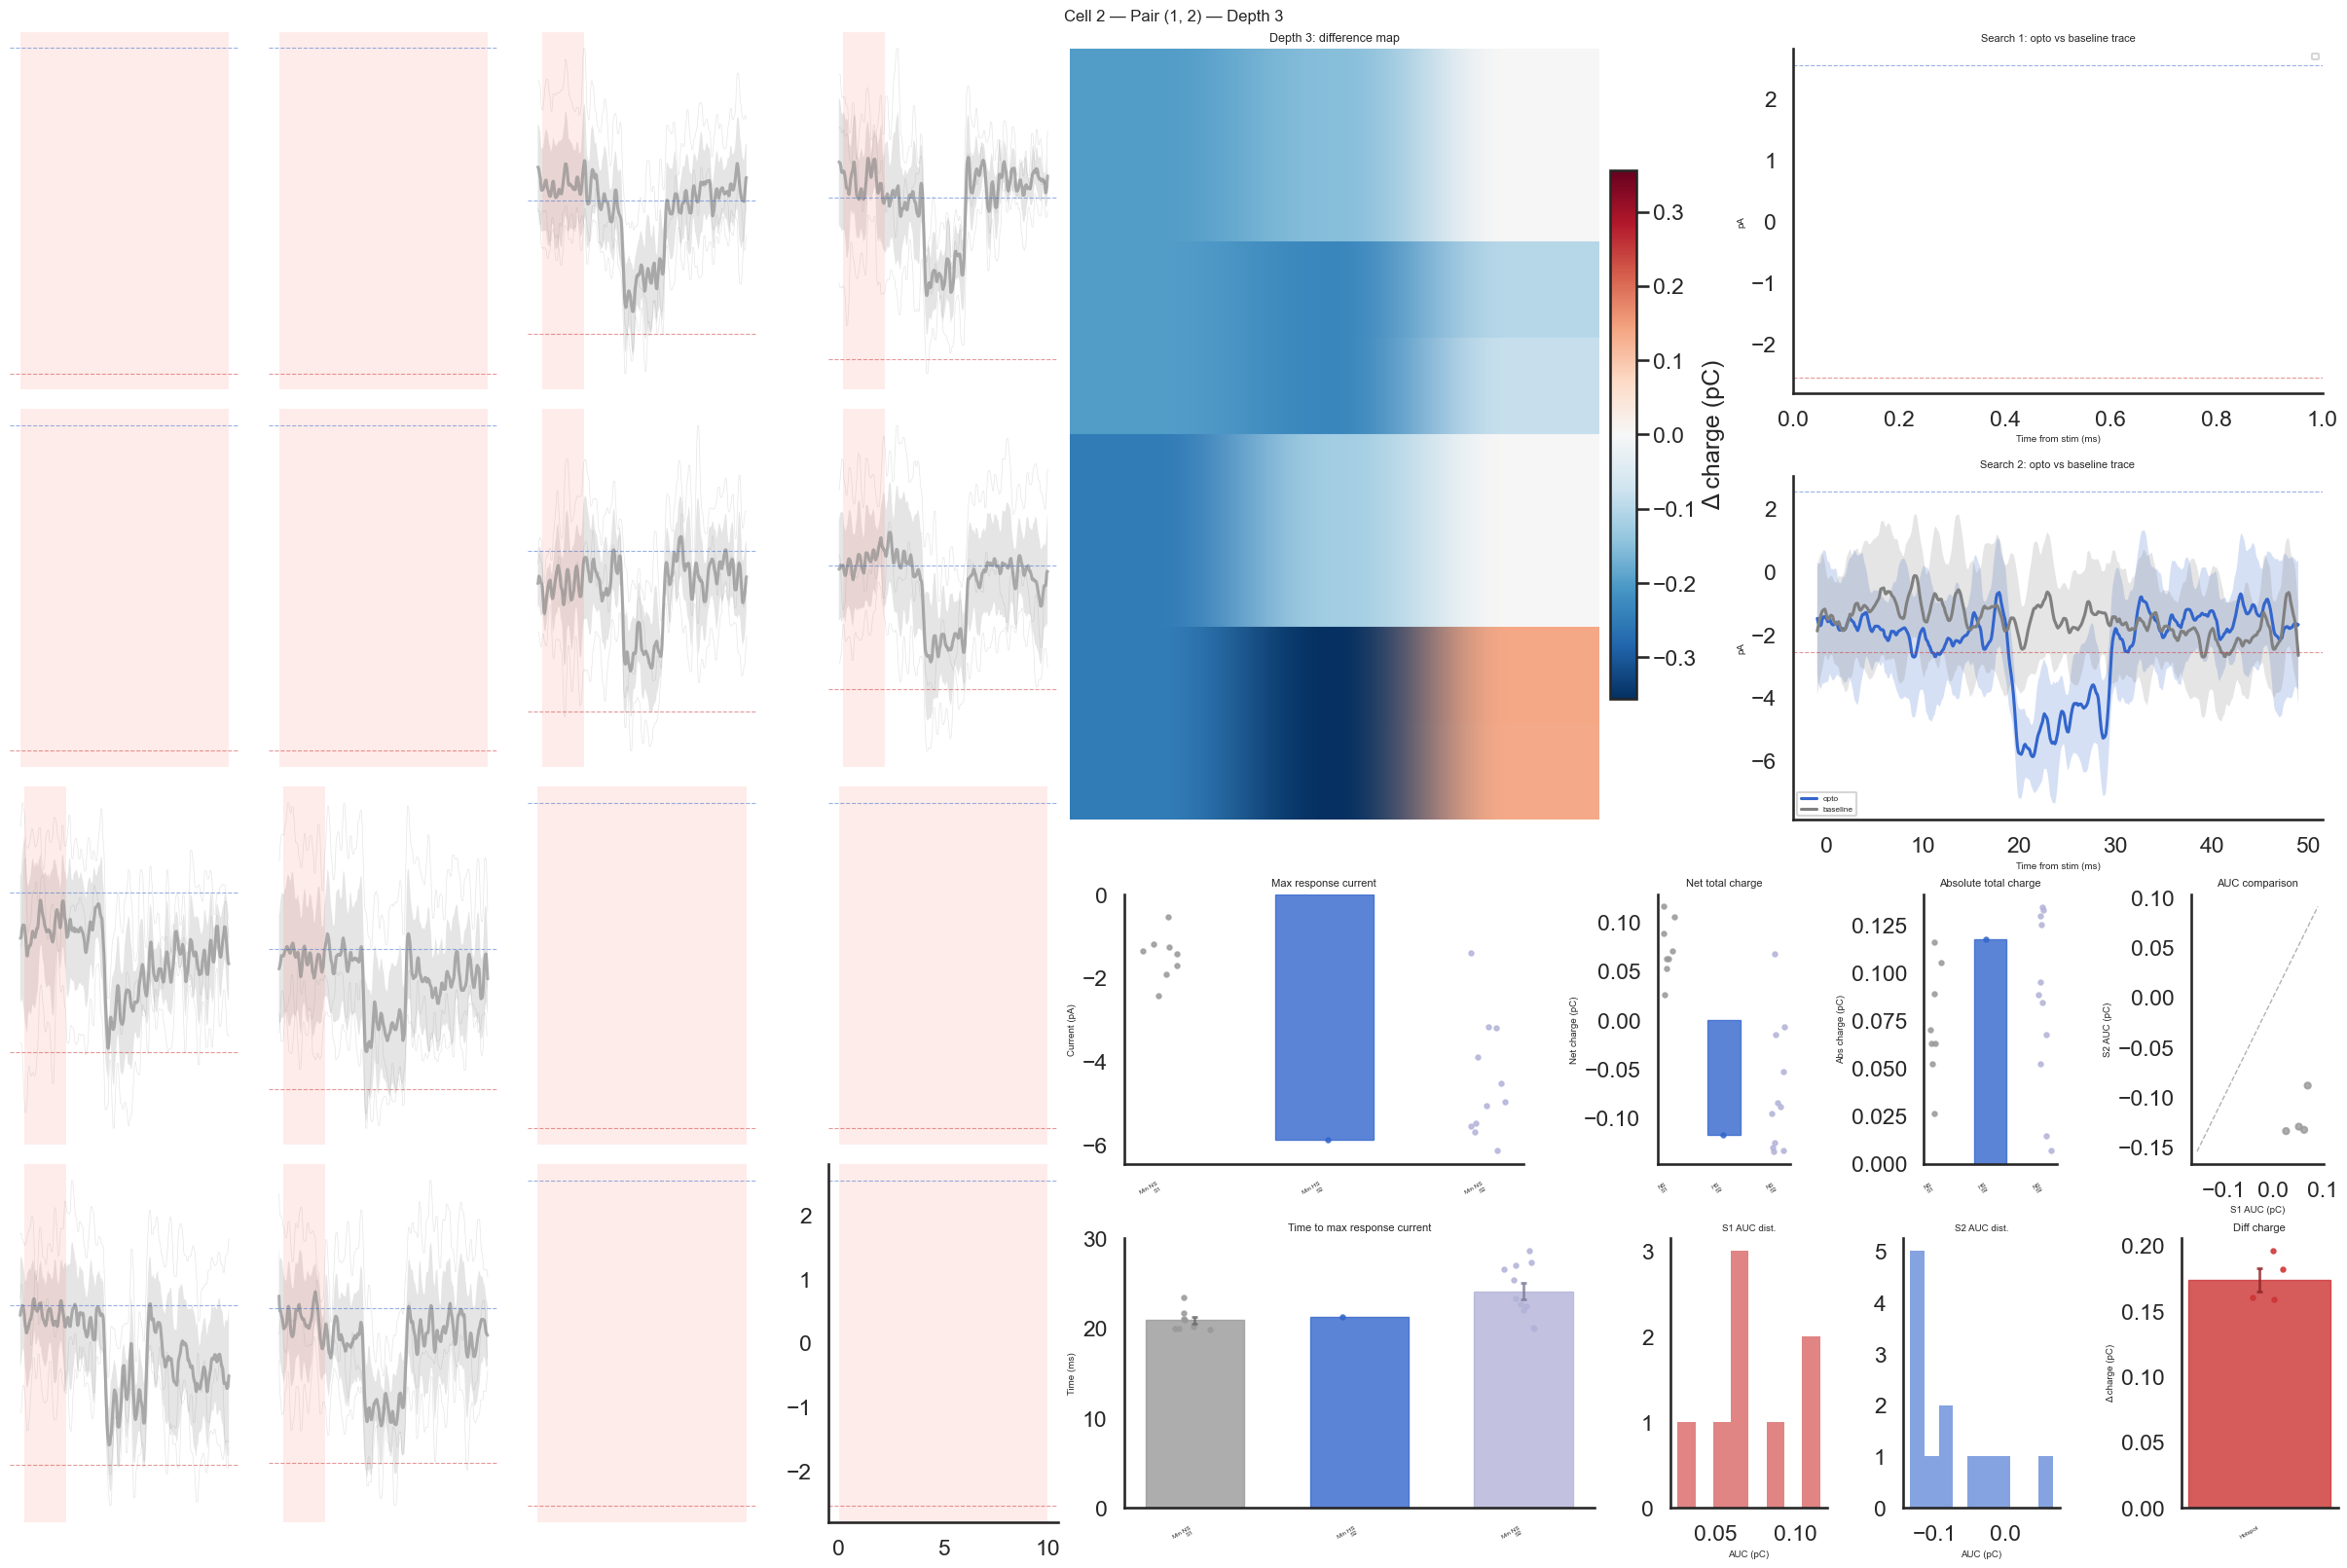

In [11]:
pair_result = ndap.analyze_dmd_search_pair(
    cells_df,
    cell=2,
    pair_idx=0,
    make_plots=True,
    save_dir=SAVE_DIR,
)

print(f"Common depths compared: {len(pair_result['depth_results'])}")
for dr in pair_result["depth_results"]:
    print(f"  depth {dr['depth']}: opto1={dr['opto1'].shape}, opto2={dr['opto2'].shape}")

In [12]:
# Per-depth AUC difference summary
pair_metrics = pair_result["metrics_df"]
pair_metrics.groupby("depth")[["auc_search1", "auc_search2", "auc_diff"]].mean().round(4)

,auc_search1,auc_search2,auc_diff
depth,,,
1,-0.0688,-0.0940,0.0252
2,-0.0887,-0.0409,-0.0478
3,0.0365,-0.0570,0.0935


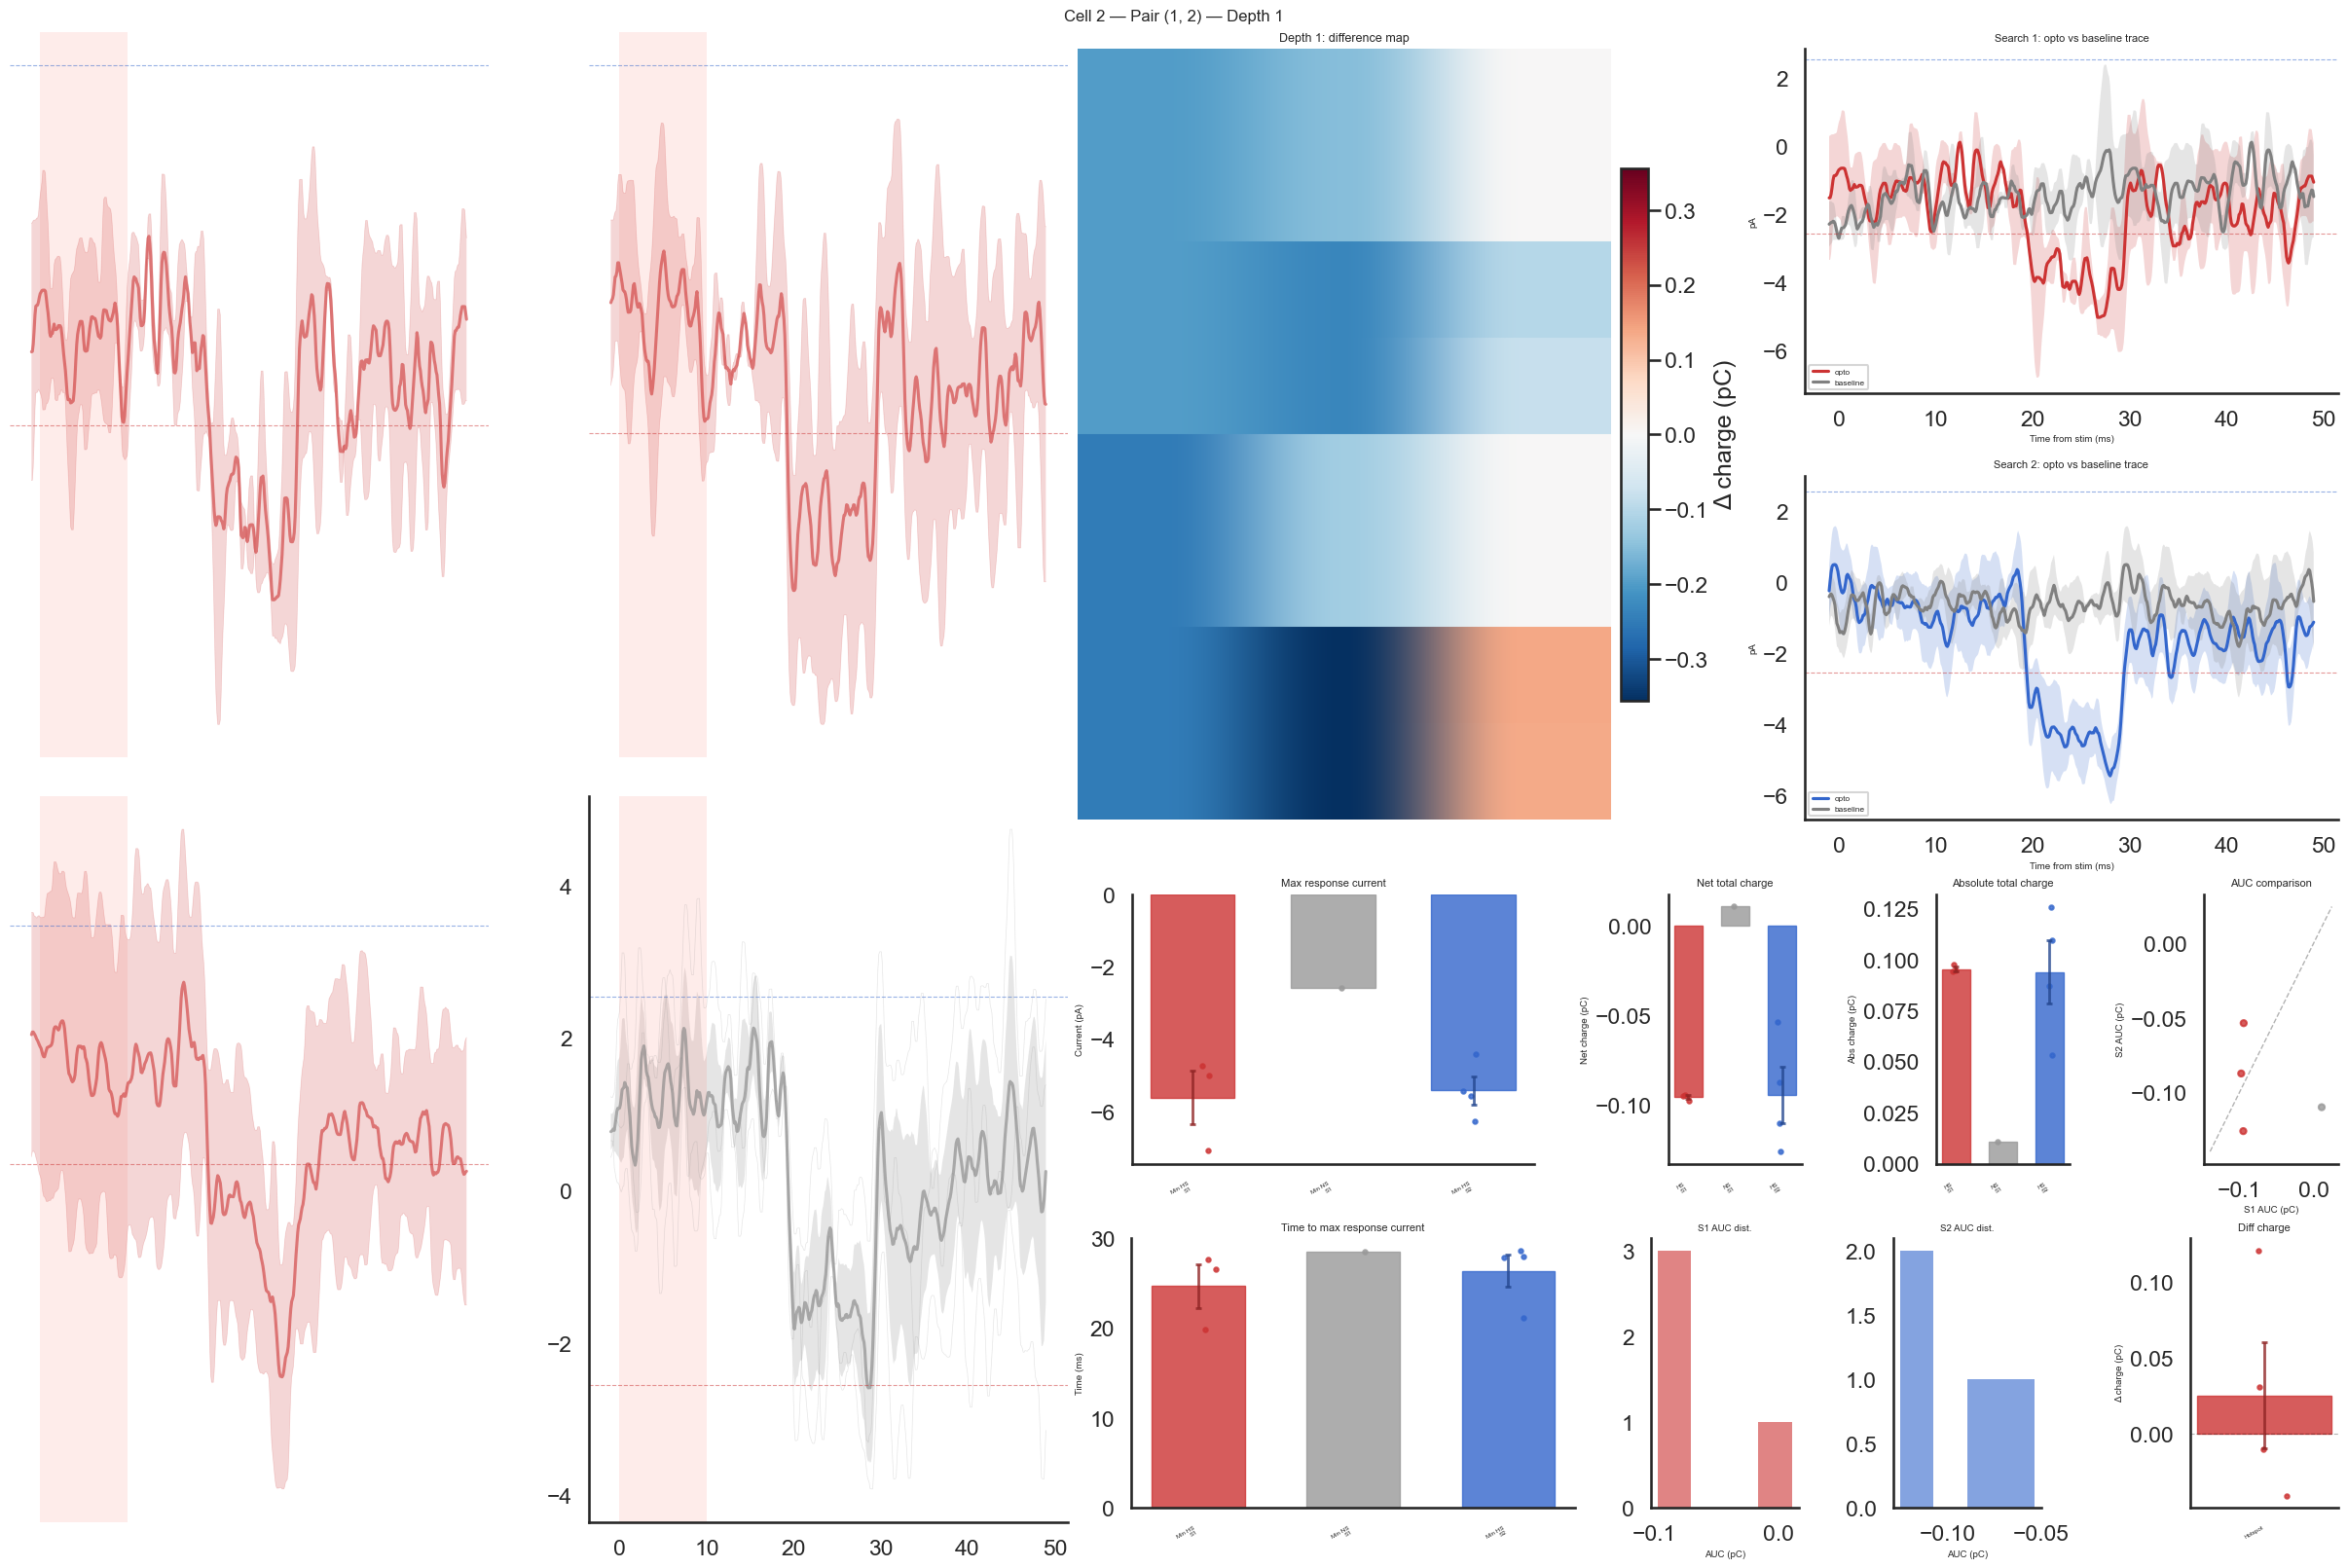

In [13]:
# Display depth-1 pair comparison figure
pair_result["figures"][0]

In [14]:
plt.close("all")
print(f"Done — figures saved to:\n  {SAVE_DIR}")

Done — figures saved to:
  /Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM/SL406/Results-20260109/python_output
